In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/rice-leaf-classification/Rice data main big'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_8034.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_9808.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_2257.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_1912.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_7593.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_9552.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_4173.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_525.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_629.jpeg
/kaggle/input/rice-leaf-classification/Rice data main big/Rice Leaffolder/Augmented_0_6102.jpeg
/kaggle/input/rice-leaf-classification/Ric

In [21]:
!pip install pytorch-lightning

In [22]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import urllib.request

try:
    print(urllib.request.urlopen("https://google.com").status)
except Exception as e:
    print("No internet:", e)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Define the device (use GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Helper Functions for Training and Validation ---
def train_model(model, train_loader, optimizer, criterion):
    """Trains the model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_model(model, val_loader, criterion):
    """Evaluates the model on the validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Model Definitions ---
class RAGModel(nn.Module):
    """Placeholder for the Retrieval-Augmented Generation model's retrieval component."""
    def __init__(self, retrieval_database=None):
        super().__init__()
        self.retrieval_database = retrieval_database

    def retrieve_features(self, query_image):
        """Simulates retrieval of a context vector."""
        # Query the RAG model and get a response (context vector)
        return torch.randn(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    """Placeholder for the Vision Large Language Model."""
    def __init__(self):
        super().__init__()

    def forward(self, context):
        """Simulates LLM processing the retrieved context to produce a new query."""
        # Use the context to produce a new query vector (feature)
        return torch.randn(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    """CNN-based model with an attention mechanism using EfficientNet backbones."""
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)

        # Remove the final classifier layers to get feature vectors
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()

        # Calculate combined feature dimension
        b0_out_dim = 1280
        b3_out_dim = 1536
        b5_out_dim = 2048
        embed_dim = b0_out_dim + b3_out_dim + b5_out_dim
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined_features = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attention_input = combined_features.unsqueeze(1)
        attention_output, _ = self.attention(attention_input, attention_input, attention_input)
        return attention_output.squeeze(1)

# --- Corrected FusionClassificationModel for the new diagram ---
class FusionClassificationModel(nn.Module):
    """The main fusion model that combines features from different branches."""
    def __init__(self, num_classes, retrieval_model):
        super().__init__()
        self.retrieval_model = retrieval_model
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()

        # Define the final classifier layer
        cnn_attention_output_size = 1280 + 1536 + 2048
        llm_output_size = 128

        self.fc = nn.Sequential(
            nn.Linear(llm_output_size + cnn_attention_output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        """Forward pass implementing the new sequential diagram."""
        # Step 1: Query the RAG model and get a response
        rag_response = self.retrieval_model.retrieve_features(x)

        # Step 2: Use the RAG response as context for the Vision LLM
        llm_features = self.vision_llm(rag_response)

        # Step 3: Process the image through the CNN-Attention branch
        cnn_attention_features = self.cnn_attention(x)

        # Step 4: Fuse the features from both branches
        combined_features = torch.cat((llm_features, cnn_attention_features), dim=1)

        # Step 5: Final classification using the fused features
        out = self.fc(combined_features)
        return out

# --- Main Script ---
if __name__ == "__main__":
    dataset_dir = "/kaggle/input/rice-leaf-classification/Rice data main big"
    transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize image
    ])

    try:
        dataset = datasets.ImageFolder(root=dataset_dir, transform=transform)

        # Split data into train/val/test sets
        train_val_ratio = 0.8
        train_val_size = int(len(dataset) * train_val_ratio)
        test_size = len(dataset) - train_val_size
        train_val_dataset, test_dataset = random_split(dataset, [train_val_size, test_size])

        # --- Corrected k-fold function (from previous response) ---
        def stratified_kfold(dataset, n_splits=5):
            targets = [dataset.dataset.targets[i] for i in dataset.indices]
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            for train_idx, val_idx in skf.split(np.zeros(len(targets)), targets):
                train_subset_indices = [dataset.indices[i] for i in train_idx]
                val_subset_indices = [dataset.indices[i] for i in val_idx]
                train_subset = Subset(dataset.dataset, train_subset_indices)
                val_subset = Subset(dataset.dataset, val_subset_indices)
                yield train_subset, val_subset

        fold_accuracies = []
        rag_model = RAGModel()
        N_SPLITS = 5

        kfold_generator = stratified_kfold(train_val_dataset, n_splits=N_SPLITS)

        for fold, (train_subset, val_subset) in enumerate(kfold_generator):
            print(f"\n--- Starting Fold {fold + 1}/{N_SPLITS} ---")

            # Re-initialize the model for each fold
            model = FusionClassificationModel(num_classes=len(dataset.classes), retrieval_model=rag_model).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
            criterion = nn.CrossEntropyLoss()

            train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

            train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

            for epoch in range(10):
                train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
                val_loss, val_acc = validate_model(model, val_loader, criterion)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_accuracies.append(train_acc)
                val_accuracies.append(val_acc)
                print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label="Train Loss", color='blue')
            plt.plot(val_losses, label="Validation Loss", color='red')
            plt.title(f"Loss Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

            plt.figure(figsize=(10, 5))
            plt.plot(train_accuracies, label="Train Accuracy", color='blue')
            plt.plot(val_accuracies, label="Validation Accuracy", color='red')
            plt.title(f"Accuracy Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.show()

            fold_accuracies.append(val_acc)

        average_accuracy = np.mean(fold_accuracies)
        print(f"\nAverage Validation Accuracy over {N_SPLITS} folds: {average_accuracy:.4f}")

        # Final Test Evaluation (using the last trained model)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        model.eval()
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        print("\nFinal Test Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=dataset.classes))

        cm = confusion_matrix(all_labels, all_preds)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes).plot(cmap="Blues")
        plt.title("Confusion Matrix for Test Dataset")
        plt.show()

        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(dataset.classes)):
            fpr[i], tpr[i], _ = roc_curve([1 if label == i else 0 for label in all_labels],
                                          [prob[i] for prob in all_probs])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(10, 5))
        for i in range(len(dataset.classes)):
            plt.plot(fpr[i], tpr[i], label=f"Class {dataset.classes[i]} (AUC={roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve for Test Dataset")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Save the final model
        drive_path = "/kaggle/input/rice-leaf-classification/Rice data main big/RICE_fusion.pt"
        torch.save(model.state_dict(), drive_path)
        print(f"Model saved to {drive_path}")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your dataset path is correct and the drive is mounted.")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau # Scheduler added

# Define the device (use GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Helper Functions for Training and Validation ---
def train_model(model, train_loader, optimizer, criterion):
    """Trains the model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_model(model, val_loader, criterion):
    """Evaluates the model on the validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Model Definitions ---
class RAGModel(nn.Module):
    """Placeholder for the Retrieval-Augmented Generation model's retrieval component."""
    def __init__(self, retrieval_database=None):
        super().__init__()
        self.retrieval_database = retrieval_database

    def retrieve_features(self, query_image):
        """Simulates retrieval of a context vector."""
        # MODIFICATION: Changed randn to zeros to remove noise confusion
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    """Placeholder for the Vision Large Language Model."""
    def __init__(self):
        super().__init__()

    def forward(self, context):
        """Simulates LLM processing the retrieved context to produce a new query."""
        # MODIFICATION: Changed randn to zeros to remove noise confusion
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    """CNN-based model with an attention mechanism using EfficientNet backbones."""
    def __init__(self):
        super().__init__()
        # Using pretrained weights is crucial for high accuracy
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)

        # Remove the final classifier layers to get feature vectors
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()

        # Calculate combined feature dimension
        b0_out_dim = 1280
        b3_out_dim = 1536
        b5_out_dim = 2048
        embed_dim = b0_out_dim + b3_out_dim + b5_out_dim
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined_features = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attention_input = combined_features.unsqueeze(1)
        attention_output, _ = self.attention(attention_input, attention_input, attention_input)
        return attention_output.squeeze(1)

# --- Corrected FusionClassificationModel for the new diagram ---
class FusionClassificationModel(nn.Module):
    """The main fusion model that combines features from different branches."""
    def __init__(self, num_classes, retrieval_model):
        super().__init__()
        self.retrieval_model = retrieval_model
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()

        # Define the final classifier layer
        cnn_attention_output_size = 1280 + 1536 + 2048
        llm_output_size = 128

        self.fc = nn.Sequential(
            nn.Linear(llm_output_size + cnn_attention_output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4), # Increased dropout slightly for regularization
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        """Forward pass implementing the new sequential diagram."""
        # Step 1: Query the RAG model and get a response
        rag_response = self.retrieval_model.retrieve_features(x)

        # Step 2: Use the RAG response as context for the Vision LLM
        llm_features = self.vision_llm(rag_response)

        # Step 3: Process the image through the CNN-Attention branch
        cnn_attention_features = self.cnn_attention(x)

        # Step 4: Fuse the features from both branches
        combined_features = torch.cat((llm_features, cnn_attention_features), dim=1)

        # Step 5: Final classification using the fused features
        out = self.fc(combined_features)
        return out

# --- Main Script ---
if __name__ == "__main__":
    dataset_dir = "/kaggle/input/rice-leaf-classification/Rice data main big"
    
    # MODIFICATION: High Accuracy Transforms (Augmentation + Size 224 + ImageNet Norm)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # IMPORTANT: Increased size for EfficientNet
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet Standards
    ])

    try:
        dataset = datasets.ImageFolder(root=dataset_dir, transform=transform)

        # Split data into train/val/test sets
        train_val_ratio = 0.8
        train_val_size = int(len(dataset) * train_val_ratio)
        test_size = len(dataset) - train_val_size
        train_val_dataset, test_dataset = random_split(dataset, [train_val_size, test_size])

        # --- Corrected k-fold function (from previous response) ---
        def stratified_kfold(dataset, n_splits=5):
            targets = [dataset.dataset.targets[i] for i in dataset.indices]
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            for train_idx, val_idx in skf.split(np.zeros(len(targets)), targets):
                train_subset_indices = [dataset.indices[i] for i in train_idx]
                val_subset_indices = [dataset.indices[i] for i in val_idx]
                train_subset = Subset(dataset.dataset, train_subset_indices)
                val_subset = Subset(dataset.dataset, val_subset_indices)
                yield train_subset, val_subset

        fold_accuracies = []
        rag_model = RAGModel()
        N_SPLITS = 3
        
        # MODIFICATION: Increased Epochs
        NUM_EPOCHS = 25 
        BATCH_SIZE = 16 # Reduced batch size to handle 3 EfficientNets with 224x224 images

        kfold_generator = stratified_kfold(train_val_dataset, n_splits=N_SPLITS)

        for fold, (train_subset, val_subset) in enumerate(kfold_generator):
            print(f"\n--- Starting Fold {fold + 1}/{N_SPLITS} ---")

            # Re-initialize the model for each fold
            model = FusionClassificationModel(num_classes=len(dataset.classes), retrieval_model=rag_model).to(device)
            
            # MODIFICATION: Use AdamW and a Scheduler
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
            criterion = nn.CrossEntropyLoss()

            train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
            val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

            train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
            
            best_fold_acc = 0.0

            for epoch in range(NUM_EPOCHS):
                train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
                val_loss, val_acc = validate_model(model, val_loader, criterion)
                
                # Step the scheduler based on validation accuracy
                scheduler.step(val_acc)

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_accuracies.append(train_acc)
                val_accuracies.append(val_acc)
                
                if val_acc > best_fold_acc:
                    best_fold_acc = val_acc
                    # Optional: Save best model per fold if needed
                    # torch.save(model.state_dict(), f"best_model_fold_{fold}.pt")

                print(f"Epoch {epoch + 1}/{NUM_EPOCHS}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label="Train Loss", color='blue')
            plt.plot(val_losses, label="Validation Loss", color='red')
            plt.title(f"Loss Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

            plt.figure(figsize=(10, 5))
            plt.plot(train_accuracies, label="Train Accuracy", color='blue')
            plt.plot(val_accuracies, label="Validation Accuracy", color='red')
            plt.title(f"Accuracy Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.show()

            fold_accuracies.append(best_fold_acc) # Store best accuracy of the fold

        average_accuracy = np.mean(fold_accuracies)
        print(f"\nAverage Best Validation Accuracy over {N_SPLITS} folds: {average_accuracy:.4f}")

        # Final Test Evaluation (using the last trained model instance)
        # Note: Ideally, you would load the overall best saved model here.
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        model.eval()
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        print("\nFinal Test Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=dataset.classes))

        cm = confusion_matrix(all_labels, all_preds)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes).plot(cmap="Blues")
        plt.title("Confusion Matrix for Test Dataset")
        plt.show()

        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(dataset.classes)):
            fpr[i], tpr[i], _ = roc_curve([1 if label == i else 0 for label in all_labels],
                                          [prob[i] for prob in all_probs])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(10, 5))
        for i in range(len(dataset.classes)):
            plt.plot(fpr[i], tpr[i], label=f"Class {dataset.classes[i]} (AUC={roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve for Test Dataset")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Save the final model
        drive_path = "/kaggle/working/RICE_fusion_high_acc.pt" # Saved to working dir to avoid permission issues
        torch.save(model.state_dict(), drive_path)
        print(f"Model saved to {drive_path}")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your dataset path is correct and the drive is mounted.")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau # Scheduler added

# Define the device (use GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Helper Functions for Training and Validation ---
def train_model(model, train_loader, optimizer, criterion):
    """Trains the model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_model(model, val_loader, criterion):
    """Evaluates the model on the validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Model Definitions ---
class RAGModel(nn.Module):
    """Placeholder for the Retrieval-Augmented Generation model's retrieval component."""
    def __init__(self, retrieval_database=None):
        super().__init__()
        self.retrieval_database = retrieval_database

    def retrieve_features(self, query_image):
        """Simulates retrieval of a context vector."""
        # MODIFICATION: Changed randn to zeros to remove noise confusion
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    """Placeholder for the Vision Large Language Model."""
    def __init__(self):
        super().__init__()

    def forward(self, context):
        """Simulates LLM processing the retrieved context to produce a new query."""
        # MODIFICATION: Changed randn to zeros to remove noise confusion
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    """CNN-based model with an attention mechanism using EfficientNet backbones."""
    def __init__(self):
        super().__init__()
        # Using pretrained weights is crucial for high accuracy
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)

        # Remove the final classifier layers to get feature vectors
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()

        # Calculate combined feature dimension
        b0_out_dim = 1280
        b3_out_dim = 1536
        b5_out_dim = 2048
        embed_dim = b0_out_dim + b3_out_dim + b5_out_dim
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined_features = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attention_input = combined_features.unsqueeze(1)
        attention_output, _ = self.attention(attention_input, attention_input, attention_input)
        return attention_output.squeeze(1)

# --- Corrected FusionClassificationModel for the new diagram ---
class FusionClassificationModel(nn.Module):
    """The main fusion model that combines features from different branches."""
    def __init__(self, num_classes, retrieval_model):
        super().__init__()
        self.retrieval_model = retrieval_model
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()

        # Define the final classifier layer
        cnn_attention_output_size = 1280 + 1536 + 2048
        llm_output_size = 128

        self.fc = nn.Sequential(
            nn.Linear(llm_output_size + cnn_attention_output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4), # Increased dropout slightly for regularization
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        """Forward pass implementing the new sequential diagram."""
        # Step 1: Query the RAG model and get a response
        rag_response = self.retrieval_model.retrieve_features(x)

        # Step 2: Use the RAG response as context for the Vision LLM
        llm_features = self.vision_llm(rag_response)

        # Step 3: Process the image through the CNN-Attention branch
        cnn_attention_features = self.cnn_attention(x)

        # Step 4: Fuse the features from both branches
        combined_features = torch.cat((llm_features, cnn_attention_features), dim=1)

        # Step 5: Final classification using the fused features
        out = self.fc(combined_features)
        return out

# --- Main Script ---
if __name__ == "__main__":
    dataset_dir = "/kaggle/input/rice-leaf-classification/Rice data main big"
    
    # MODIFICATION: High Accuracy Transforms (Augmentation + Size 224 + ImageNet Norm)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # IMPORTANT: Increased size for EfficientNet
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet Standards
    ])

    try:
        dataset = datasets.ImageFolder(root=dataset_dir, transform=transform)

        # Split data into train/val/test sets
        train_val_ratio = 0.8
        train_val_size = int(len(dataset) * train_val_ratio)
        test_size = len(dataset) - train_val_size
        train_val_dataset, test_dataset = random_split(dataset, [train_val_size, test_size])

        # --- Corrected k-fold function (from previous response) ---
        def stratified_kfold(dataset, n_splits=5):
            targets = [dataset.dataset.targets[i] for i in dataset.indices]
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            for train_idx, val_idx in skf.split(np.zeros(len(targets)), targets):
                train_subset_indices = [dataset.indices[i] for i in train_idx]
                val_subset_indices = [dataset.indices[i] for i in val_idx]
                train_subset = Subset(dataset.dataset, train_subset_indices)
                val_subset = Subset(dataset.dataset, val_subset_indices)
                yield train_subset, val_subset

        fold_accuracies = []
        rag_model = RAGModel()
        N_SPLITS = 3
        
        # MODIFICATION: Increased Epochs
        NUM_EPOCHS = 25 
        BATCH_SIZE = 16 # Reduced batch size to handle 3 EfficientNets with 224x224 images

        kfold_generator = stratified_kfold(train_val_dataset, n_splits=N_SPLITS)

        for fold, (train_subset, val_subset) in enumerate(kfold_generator):
            print(f"\n--- Starting Fold {fold + 1}/{N_SPLITS} ---")

            # Re-initialize the model for each fold
            model = FusionClassificationModel(num_classes=len(dataset.classes), retrieval_model=rag_model).to(device)
            
            # MODIFICATION: Use AdamW and a Scheduler
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
            criterion = nn.CrossEntropyLoss()

            train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
            val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

            train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
            
            best_fold_acc = 0.0

            for epoch in range(NUM_EPOCHS):
                train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
                val_loss, val_acc = validate_model(model, val_loader, criterion)
                
                # Step the scheduler based on validation accuracy
                scheduler.step(val_acc)

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_accuracies.append(train_acc)
                val_accuracies.append(val_acc)
                
                if val_acc > best_fold_acc:
                    best_fold_acc = val_acc
                    # Optional: Save best model per fold if needed
                    # torch.save(model.state_dict(), f"best_model_fold_{fold}.pt")

                print(f"Epoch {epoch + 1}/{NUM_EPOCHS}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label="Train Loss", color='blue')
            plt.plot(val_losses, label="Validation Loss", color='red')
            plt.title(f"Loss Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

            plt.figure(figsize=(10, 5))
            plt.plot(train_accuracies, label="Train Accuracy", color='blue')
            plt.plot(val_accuracies, label="Validation Accuracy", color='red')
            plt.title(f"Accuracy Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.show()

            fold_accuracies.append(best_fold_acc) # Store best accuracy of the fold

        average_accuracy = np.mean(fold_accuracies)
        print(f"\nAverage Best Validation Accuracy over {N_SPLITS} folds: {average_accuracy:.4f}")

        # Final Test Evaluation (using the last trained model instance)
        # Note: Ideally, you would load the overall best saved model here.
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        model.eval()
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        print("\nFinal Test Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=dataset.classes))

        cm = confusion_matrix(all_labels, all_preds)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes).plot(cmap="Blues")
        plt.title("Confusion Matrix for Test Dataset")
        plt.show()

        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(dataset.classes)):
            fpr[i], tpr[i], _ = roc_curve([1 if label == i else 0 for label in all_labels],
                                          [prob[i] for prob in all_probs])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(10, 5))
        for i in range(len(dataset.classes)):
            plt.plot(fpr[i], tpr[i], label=f"Class {dataset.classes[i]} (AUC={roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve for Test Dataset")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Save the final model
        drive_path = "/kaggle/working/RICE_fusion_high_acc.pt" # Saved to working dir to avoid permission issues
        torch.save(model.state_dict(), drive_path)
        print(f"Model saved to {drive_path}")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your dataset path is correct and the drive is mounted.")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# --- 1. Configuration & Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset Path (Change if needed)
DATASET_DIR = "/kaggle/input/rice-leaf-classification/Rice data main big"
NUM_EPOCHS = 25   # Adjust as needed (e.g., 25-30 for better results)
BATCH_SIZE = 16
NUM_FOLDS = 2     # K-Fold splits

# --- 2. Custom Transform Classes (For Robustness) ---
class AddGaussianNoise(object):
    """Custom transform to add Gaussian noise to an image tensor."""
    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean
    
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

# --- 3. Model Definitions ---
class RAGModel(nn.Module):
    def __init__(self):
        super().__init__()
    def retrieve_features(self, query_image):
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, context):
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)
        
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()
        
        embed_dim = 1280 + 1536 + 2048
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attn_in = combined.unsqueeze(1)
        attn_out, _ = self.attention(attn_in, attn_in, attn_in)
        return attn_out.squeeze(1)

class FusionClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.retrieval_model = RAGModel()
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        
        input_dim = 128 + (1280 + 1536 + 2048)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        rag_feat = self.retrieval_model.retrieve_features(x)
        llm_feat = self.vision_llm(rag_feat)
        cnn_feat = self.cnn_attention(x)
        fused = torch.cat((llm_feat, cnn_feat), dim=1)
        return self.fc(fused)

# --- 4. Training Helper Functions ---
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

# --- 5. Robustness Testing Functions ---
def get_robust_test_loader(dataset_subset, scenario, batch_size=42):
    """Creates a DataLoader with specific transforms based on the scenario."""
    
    # Base transforms (Resize)
    base_transforms = [transforms.Resize((224, 224))]
    
    # Scenario specific modifications
    if scenario == 'Blur':
        base_transforms.append(transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)))
    elif scenario == 'Low_Light':
        base_transforms.append(transforms.ColorJitter(brightness=(0.2, 0.3))) # Very low brightness
    elif scenario == 'Rotation':
        base_transforms.append(transforms.RandomRotation(degrees=(45, 90)))
    
    # Common ending transforms
    base_transforms.append(transforms.ToTensor())
    
    if scenario == 'Noise':
        base_transforms.append(AddGaussianNoise(0., 0.15)) # Add noise after tensor conversion
        
    base_transforms.append(transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]))
    
    # Create a new dataset with these transforms
    # We copy the subset logic but apply new transforms
    # Note: Accessing the underlying dataset file path from subset is tricky, 
    # so we wrap the subset with a Transform class
    
    class ApplyTransform(torch.utils.data.Dataset):
        def __init__(self, subset, transform=None):
            self.subset = subset
            self.transform = transform
            
        def __getitem__(self, index):
            x, y = self.subset[index]
            # x is already a tensor if coming from original dataset, 
            # so we need to be careful. Ideally, we load from ImageFolder again.
            # To simplify: We assume original dataset loaded PIL images (no transform initially)
            # OR we re-transform the PIL image. 
            # *Hack for Kaggle*: The original dataset has a transform. 
            # To implement robust transforms correctly on subsets, we should override.
            return self.transform(x), y # This assumes x is PIL. 
            
            # Since 'dataset' in main has transforms, x will be tensor.
            # We need to access the raw sample.
            
        def __len__(self):
            return len(self.subset)

    # Re-definition for safety: access original ImageFolder samples
    indices = dataset_subset.indices
    original_dataset = dataset_subset.dataset
    
    # We need a custom dataset class that retrieves the image as PIL from path
    class RobustDataset(torch.utils.data.Dataset):
        def __init__(self, root_dataset, indices, transform):
            self.root_dataset = root_dataset
            self.indices = indices
            self.transform = transform
        def __len__(self): return len(self.indices)
        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            path, target = self.root_dataset.samples[real_idx]
            sample = self.root_dataset.loader(path) # Load PIL
            if self.transform:
                sample = self.transform(sample)
            return sample, target

    custom_transform = transforms.Compose(base_transforms)
    robust_ds = RobustDataset(dataset_subset.dataset, dataset_subset.indices, custom_transform)
    
    return DataLoader(robust_ds, batch_size=batch_size, shuffle=False)

def evaluate_and_plot(model, loader, classes, scenario_name):
    """Evaluates the model and plots Classification Report, Matrix, and ROC."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*20} Results for: {scenario_name} {'='*20}")
    
    # 1. Classification Report
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - {scenario_name}")
    plt.show()
    
    # 3. ROC Curve
    fpr, tpr, roc_auc = {}, {}, {}
    n_classes = len(classes)
    
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        # One-vs-Rest ROC
        binary_labels = [1 if label == i else 0 for label in all_labels]
        prob_i = [p[i] for p in all_probs]
        fpr[i], tpr[i], _ = roc_curve(binary_labels, prob_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')
        
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve - {scenario_name}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

# --- 6. Main Execution Block ---
if __name__ == "__main__":
    try:
        # Load Dataset (Initial Standard Transform)
        standard_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=standard_transform)
        class_names = full_dataset.classes
        print(f"Classes found: {class_names}")

        # Split: 80% Train+Val, 20% Test (Reserved for Robustness Testing)
        train_val_size = int(0.8 * len(full_dataset))
        test_size = len(full_dataset) - train_val_size
        train_val_ds, test_ds = random_split(full_dataset, [train_val_size, test_size])
        
        # --- PHASE 1: K-Fold Training ---
        skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
        
        # Get targets for stratification
        targets = [full_dataset.targets[i] for i in train_val_ds.indices]
        
        best_model_wts = None
        best_acc_global = 0.0
        
        # We will only run training loop logic here
        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
            print(f"\n--- Training Fold {fold + 1}/{NUM_FOLDS} ---")
            
            # Subsets
            train_subset = Subset(full_dataset, [train_val_ds.indices[i] for i in train_idx])
            val_subset = Subset(full_dataset, [train_val_ds.indices[i] for i in val_idx])
            
            train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
            
            # Initialize Model
            model = FusionClassificationModel(num_classes=len(class_names)).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
            criterion = nn.CrossEntropyLoss()
            
            train_losses, val_losses = [], []
            train_accs, val_accs = [], []
            
            # Epoch Loop
            for epoch in range(NUM_EPOCHS):
                t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
                v_loss, v_acc = validate_one_epoch(model, val_loader, criterion)
                
                scheduler.step(v_acc)
                
                train_losses.append(t_loss)
                val_losses.append(v_loss)
                train_accs.append(t_acc)
                val_accs.append(v_acc)
                
                print(f"Epoch {epoch+1}: T-Loss: {t_loss:.4f} T-Acc: {t_acc:.4f} | V-Loss: {v_loss:.4f} V-Acc: {v_acc:.4f}")
                
                # Save best global model
                if v_acc > best_acc_global:
                    best_acc_global = v_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
            
            # Plot Loss/Accuracy for this Fold
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label='Train')
            plt.plot(val_losses, label='Val')
            plt.title(f"Fold {fold+1} Loss Curve")
            plt.legend()
            
            plt.subplot(1, 2, 2)
            plt.plot(train_accs, label='Train')
            plt.plot(val_accs, label='Val')
            plt.title(f"Fold {fold+1} Accuracy Curve")
            plt.legend()
            plt.show()

        print(f"\nTraining Complete. Best Validation Accuracy: {best_acc_global:.4f}")
        
        # Save Best Model to Disk
        save_path = "best_fusion_model.pth"
        torch.save(best_model_wts, save_path)
        print(f"Best model saved to {save_path}")

        # --- PHASE 2: Robustness Testing (The Multi-Scenario Loop) ---
        print("\n\n" + "#"*30)
        print("STARTING ROBUSTNESS & STRESS TESTING")
        print("#"*30)
        
        # Load best weights
        final_model = FusionClassificationModel(num_classes=len(class_names)).to(device)
        final_model.load_state_dict(torch.load(save_path))
        
        scenarios = ['Normal', 'Blur', 'Noise', 'Rotation', 'Low_Light']
        
        # Create a summary table list
        summary_results = []

        for case in scenarios:
            print(f"\n>>> Preparing Test Scenario: {case}...")
            
            # Generate specific loader for this scenario using the Test Split
            robust_loader = get_robust_test_loader(test_ds, case, batch_size=BATCH_SIZE)
            
            # Run Evaluation
            evaluate_and_plot(final_model, robust_loader, class_names, case)
            
            # (Optional) Quick metric for summary table
            # You can extract accuracy from the report if needed, or recalculate briefly
            # Here we just proceed to next case
        
        print("\nAll Robustness Tests Completed Successfully.")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please check dataset path and libraries.")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# --- 1. Configuration & Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset Path (Change if needed)
DATASET_DIR = "/kaggle/input/rice-leaf-classification/Rice data main big"
NUM_EPOCHS = 10   # Adjust as needed (e.g., 25-30 for better results)
BATCH_SIZE = 16
NUM_FOLDS = 2     # K-Fold splits

# --- 2. Custom Transform Classes (For Robustness) ---
class AddGaussianNoise(object):
    """Custom transform to add Gaussian noise to an image tensor."""
    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean
    
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

# --- 3. Model Definitions ---
class RAGModel(nn.Module):
    def __init__(self):
        super().__init__()
    def retrieve_features(self, query_image):
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, context):
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)
        
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()
        
        embed_dim = 1280 + 1536 + 2048
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attn_in = combined.unsqueeze(1)
        attn_out, _ = self.attention(attn_in, attn_in, attn_in)
        return attn_out.squeeze(1)

class FusionClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.retrieval_model = RAGModel()
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        
        input_dim = 128 + (1280 + 1536 + 2048)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        rag_feat = self.retrieval_model.retrieve_features(x)
        llm_feat = self.vision_llm(rag_feat)
        cnn_feat = self.cnn_attention(x)
        fused = torch.cat((llm_feat, cnn_feat), dim=1)
        return self.fc(fused)

# --- 4. Training Helper Functions ---
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

# --- 5. Robustness Testing Functions ---
def get_robust_test_loader(dataset_subset, scenario, batch_size=42):
    """Creates a DataLoader with specific transforms based on the scenario."""
    
    # Base transforms (Resize)
    base_transforms = [transforms.Resize((224, 224))]
    
    # Scenario specific modifications
    if scenario == 'Blur':
        base_transforms.append(transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)))
    elif scenario == 'Low_Light':
        base_transforms.append(transforms.ColorJitter(brightness=(0.2, 0.3))) # Very low brightness
    elif scenario == 'Rotation':
        base_transforms.append(transforms.RandomRotation(degrees=(45, 90)))
    
    # Common ending transforms
    base_transforms.append(transforms.ToTensor())
    
    if scenario == 'Noise':
        base_transforms.append(AddGaussianNoise(0., 0.15)) # Add noise after tensor conversion
        
    base_transforms.append(transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]))
    
    # Create a new dataset with these transforms
    # We copy the subset logic but apply new transforms
    # Note: Accessing the underlying dataset file path from subset is tricky, 
    # so we wrap the subset with a Transform class
    
    class ApplyTransform(torch.utils.data.Dataset):
        def __init__(self, subset, transform=None):
            self.subset = subset
            self.transform = transform
            
        def __getitem__(self, index):
            x, y = self.subset[index]
            # x is already a tensor if coming from original dataset, 
            # so we need to be careful. Ideally, we load from ImageFolder again.
            # To simplify: We assume original dataset loaded PIL images (no transform initially)
            # OR we re-transform the PIL image. 
            # *Hack for Kaggle*: The original dataset has a transform. 
            # To implement robust transforms correctly on subsets, we should override.
            return self.transform(x), y # This assumes x is PIL. 
            
            # Since 'dataset' in main has transforms, x will be tensor.
            # We need to access the raw sample.
            
        def __len__(self):
            return len(self.subset)

    # Re-definition for safety: access original ImageFolder samples
    indices = dataset_subset.indices
    original_dataset = dataset_subset.dataset
    
    # We need a custom dataset class that retrieves the image as PIL from path
    class RobustDataset(torch.utils.data.Dataset):
        def __init__(self, root_dataset, indices, transform):
            self.root_dataset = root_dataset
            self.indices = indices
            self.transform = transform
        def __len__(self): return len(self.indices)
        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            path, target = self.root_dataset.samples[real_idx]
            sample = self.root_dataset.loader(path) # Load PIL
            if self.transform:
                sample = self.transform(sample)
            return sample, target

    custom_transform = transforms.Compose(base_transforms)
    robust_ds = RobustDataset(dataset_subset.dataset, dataset_subset.indices, custom_transform)
    
    return DataLoader(robust_ds, batch_size=batch_size, shuffle=False)

def evaluate_and_plot(model, loader, classes, scenario_name):
    """Evaluates the model and plots Classification Report, Matrix, and ROC."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*20} Results for: {scenario_name} {'='*20}")
    
    # 1. Classification Report
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - {scenario_name}")
    plt.show()
    
    # 3. ROC Curve
    fpr, tpr, roc_auc = {}, {}, {}
    n_classes = len(classes)
    
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        # One-vs-Rest ROC
        binary_labels = [1 if label == i else 0 for label in all_labels]
        prob_i = [p[i] for p in all_probs]
        fpr[i], tpr[i], _ = roc_curve(binary_labels, prob_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')
        
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve - {scenario_name}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

# --- 6. Main Execution Block ---
if __name__ == "__main__":
    try:
        # Load Dataset (Initial Standard Transform)
        standard_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=standard_transform)
        class_names = full_dataset.classes
        print(f"Classes found: {class_names}")

        # Split: 80% Train+Val, 20% Test (Reserved for Robustness Testing)
        train_val_size = int(0.8 * len(full_dataset))
        test_size = len(full_dataset) - train_val_size
        train_val_ds, test_ds = random_split(full_dataset, [train_val_size, test_size])
        
        # --- PHASE 1: K-Fold Training ---
        skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
        
        # Get targets for stratification
        targets = [full_dataset.targets[i] for i in train_val_ds.indices]
        
        best_model_wts = None
        best_acc_global = 0.0
        
        # We will only run training loop logic here
        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
            print(f"\n--- Training Fold {fold + 1}/{NUM_FOLDS} ---")
            
            # Subsets
            train_subset = Subset(full_dataset, [train_val_ds.indices[i] for i in train_idx])
            val_subset = Subset(full_dataset, [train_val_ds.indices[i] for i in val_idx])
            
            train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
            
            # Initialize Model
            model = FusionClassificationModel(num_classes=len(class_names)).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
            criterion = nn.CrossEntropyLoss()
            
            train_losses, val_losses = [], []
            train_accs, val_accs = [], []
            
            # Epoch Loop
            for epoch in range(NUM_EPOCHS):
                t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
                v_loss, v_acc = validate_one_epoch(model, val_loader, criterion)
                
                scheduler.step(v_acc)
                
                train_losses.append(t_loss)
                val_losses.append(v_loss)
                train_accs.append(t_acc)
                val_accs.append(v_acc)
                
                print(f"Epoch {epoch+1}: T-Loss: {t_loss:.4f} T-Acc: {t_acc:.4f} | V-Loss: {v_loss:.4f} V-Acc: {v_acc:.4f}")
                
                # Save best global model
                if v_acc > best_acc_global:
                    best_acc_global = v_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
            
            # Plot Loss/Accuracy for this Fold
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label='Train')
            plt.plot(val_losses, label='Val')
            plt.title(f"Fold {fold+1} Loss Curve")
            plt.legend()
            
            plt.subplot(1, 2, 2)
            plt.plot(train_accs, label='Train')
            plt.plot(val_accs, label='Val')
            plt.title(f"Fold {fold+1} Accuracy Curve")
            plt.legend()
            plt.show()

        print(f"\nTraining Complete. Best Validation Accuracy: {best_acc_global:.4f}")
        
        # Save Best Model to Disk
        save_path = "best_fusion_model.pth"
        torch.save(best_model_wts, save_path)
        print(f"Best model saved to {save_path}")

        # --- PHASE 2: Robustness Testing (The Multi-Scenario Loop) ---
        print("\n\n" + "#"*30)
        print("STARTING ROBUSTNESS & STRESS TESTING")
        print("#"*30)
        
        # Load best weights
        final_model = FusionClassificationModel(num_classes=len(class_names)).to(device)
        final_model.load_state_dict(torch.load(save_path))
        
        scenarios = ['Normal', 'Blur', 'Noise', 'Rotation', 'Low_Light']
        
        # Create a summary table list
        summary_results = []

        for case in scenarios:
            print(f"\n>>> Preparing Test Scenario: {case}...")
            
            # Generate specific loader for this scenario using the Test Split
            robust_loader = get_robust_test_loader(test_ds, case, batch_size=BATCH_SIZE)
            
            # Run Evaluation
            evaluate_and_plot(final_model, robust_loader, class_names, case)
            
            # (Optional) Quick metric for summary table
            # You can extract accuracy from the report if needed, or recalculate briefly
            # Here we just proceed to next case
        
        print("\nAll Robustness Tests Completed Successfully.")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please check dataset path and libraries.")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os

# --- 1. Configuration & Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset Path
DATASET_DIR = "/kaggle/input/rice-leaf-classification/Rice data main big"
NUM_EPOCHS = 10   # ভালো রেজাল্টের জন্য ২০-৩০ করতে পারেন
BATCH_SIZE = 8
NUM_FOLDS = 2     

# --- 2. Custom Transform Classes ---
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# --- 3. Model Definitions (Fusion, CNN, Attention) ---
class RAGModel(nn.Module):
    def __init__(self):
        super().__init__()
    def retrieve_features(self, query_image):
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, context):
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)
        
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()
        
        embed_dim = 1280 + 1536 + 2048
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attn_in = combined.unsqueeze(1)
        attn_out, _ = self.attention(attn_in, attn_in, attn_in)
        return attn_out.squeeze(1)

class FusionClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.retrieval_model = RAGModel()
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        input_dim = 128 + (1280 + 1536 + 2048)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        rag_feat = self.retrieval_model.retrieve_features(x)
        llm_feat = self.vision_llm(rag_feat)
        cnn_feat = self.cnn_attention(x)
        fused = torch.cat((llm_feat, cnn_feat), dim=1)
        return self.fc(fused)

# --- 4. Helper Functions (Train, Eval & Plot) ---
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def evaluate_and_plot(model, loader, classes, title_prefix):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*15} {title_prefix} Reports {'='*15}")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
    plt.title(f"Confusion Matrix: {title_prefix}")
    plt.show()
    
    # ROC Curves
    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        binary_labels = [1 if label == i else 0 for label in all_labels]
        prob_i = [p[i] for p in all_probs]
        fpr, tpr, _ = roc_curve(binary_labels, prob_i)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve: {title_prefix}")
    plt.legend(loc="lower right")
    plt.show()

# --- 5. Main Execution Block ---
if __name__ == "__main__":
    try:
        standard_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=standard_transform)
        class_names = full_dataset.classes
        print(f"Classes found: {class_names}")

        train_val_size = int(0.8 * len(full_dataset))
        test_size = len(full_dataset) - train_val_size
        train_val_ds, test_ds = random_split(full_dataset, [train_val_size, test_size])
        
        skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
        targets = [full_dataset.targets[i] for i in train_val_ds.indices]
        
        best_acc_global = 0.0
        best_model_wts = None

        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
            print(f"\n" + "#"*40)
            print(f"### STARTING FOLD {fold + 1} / {NUM_FOLDS} ###")
            print("#"*40)
            
            train_sub = Subset(full_dataset, [train_val_ds.indices[i] for i in train_idx])
            val_sub = Subset(full_dataset, [train_val_ds.indices[i] for i in val_idx])
            
            train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)
            
            model = FusionClassificationModel(num_classes=len(class_names)).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            criterion = nn.CrossEntropyLoss()
            
            t_loss_h, v_loss_h, t_acc_h, v_acc_h = [], [], [], []

            for epoch in range(NUM_EPOCHS):
                t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
                v_loss, v_acc = validate_one_epoch(model, val_loader, criterion)
                
                t_loss_h.append(t_loss); v_loss_h.append(v_loss)
                t_acc_h.append(t_acc); v_acc_h.append(v_acc)
                
                # আপনার কাঙ্ক্ষিত প্রিন্ট ফরম্যাট
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> "
                      f"T-Loss: {t_loss:.44f} T-Acc: {t_acc:.4f} | "
                      f"V-Loss: {v_loss:.4f} V-Acc: {v_acc:.4f}")

                if v_acc > best_acc_global:
                    best_acc_global = v_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            # --- Fold শেষে ভিজ্যুয়ালাইজেশন ---
            
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(t_loss_h, label='Train Loss', color='tab:blue', linewidth=2)
            plt.plot(v_loss_h, label='Val Loss', color='tab:red', linestyle='--')
            plt.title(f"Fold {fold+1}: Loss Curve")
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(t_acc_h, label='Train Acc', color='tab:green', linewidth=2)
            plt.plot(v_acc_h, label='Val Acc', color='tab:orange', linestyle='--')
            plt.title(f"Fold {fold+1}: Accuracy Curve")
            plt.legend()
            plt.show()

            # --- Fold শেষে পূর্ণাঙ্গ রিপোর্ট ---
            
            evaluate_and_plot(model, val_loader, class_names, f"Fold {fold+1}")

        # Final Save
        save_path = "best_fusion_model.pth"
        torch.save(best_model_wts, save_path)
        print(f"\n🚀 Training Complete! Best Accuracy Across Folds: {best_acc_global:.4f}")

    except Exception as e:
        print(f"❌ Error: {e}")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# --- 1. Configuration & Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset Path (Change if needed)
DATASET_DIR = "/kaggle/input/rice-leaf-classification/Rice data main big"
NUM_EPOCHS = 10   # Adjust as needed (e.g., 25-30 for better results)
BATCH_SIZE = 16
NUM_FOLDS = 2     # K-Fold splits

# --- 2. Custom Transform Classes (For Robustness) ---
class AddGaussianNoise(object):
    """Custom transform to add Gaussian noise to an image tensor."""
    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean
    
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

# --- 3. Model Definitions ---
class RAGModel(nn.Module):
    def __init__(self):
        super().__init__()
    def retrieve_features(self, query_image):
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, context):
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)
        
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()
        
        embed_dim = 1280 + 1536 + 2048
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attn_in = combined.unsqueeze(1)
        attn_out, _ = self.attention(attn_in, attn_in, attn_in)
        return attn_out.squeeze(1)

class FusionClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.retrieval_model = RAGModel()
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        
        input_dim = 128 + (1280 + 1536 + 2048)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        rag_feat = self.retrieval_model.retrieve_features(x)
        llm_feat = self.vision_llm(rag_feat)
        cnn_feat = self.cnn_attention(x)
        fused = torch.cat((llm_feat, cnn_feat), dim=1)
        return self.fc(fused)

# --- 4. Training Helper Functions ---
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

# --- 5. Robustness Testing Functions ---
def get_robust_test_loader(dataset_subset, scenario, batch_size=42):
    """Creates a DataLoader with specific transforms based on the scenario."""
    
    # Base transforms (Resize)
    base_transforms = [transforms.Resize((224, 224))]
    
    # Scenario specific modifications
    if scenario == 'Blur':
        base_transforms.append(transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)))
    elif scenario == 'Low_Light':
        base_transforms.append(transforms.ColorJitter(brightness=(0.2, 0.3))) # Very low brightness
    elif scenario == 'Rotation':
        base_transforms.append(transforms.RandomRotation(degrees=(45, 90)))
    
    # Common ending transforms
    base_transforms.append(transforms.ToTensor())
    
    if scenario == 'Noise':
        base_transforms.append(AddGaussianNoise(0., 0.15)) # Add noise after tensor conversion
        
    base_transforms.append(transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]))
    
    # Create a new dataset with these transforms
    # We copy the subset logic but apply new transforms
    # Note: Accessing the underlying dataset file path from subset is tricky, 
    # so we wrap the subset with a Transform class
    
    class ApplyTransform(torch.utils.data.Dataset):
        def __init__(self, subset, transform=None):
            self.subset = subset
            self.transform = transform
            
        def __getitem__(self, index):
            x, y = self.subset[index]
            # x is already a tensor if coming from original dataset, 
            # so we need to be careful. Ideally, we load from ImageFolder again.
            # To simplify: We assume original dataset loaded PIL images (no transform initially)
            # OR we re-transform the PIL image. 
            # *Hack for Kaggle*: The original dataset has a transform. 
            # To implement robust transforms correctly on subsets, we should override.
            return self.transform(x), y # This assumes x is PIL. 
            
            # Since 'dataset' in main has transforms, x will be tensor.
            # We need to access the raw sample.
            
        def __len__(self):
            return len(self.subset)

    # Re-definition for safety: access original ImageFolder samples
    indices = dataset_subset.indices
    original_dataset = dataset_subset.dataset
    
    # We need a custom dataset class that retrieves the image as PIL from path
    class RobustDataset(torch.utils.data.Dataset):
        def __init__(self, root_dataset, indices, transform):
            self.root_dataset = root_dataset
            self.indices = indices
            self.transform = transform
        def __len__(self): return len(self.indices)
        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            path, target = self.root_dataset.samples[real_idx]
            sample = self.root_dataset.loader(path) # Load PIL
            if self.transform:
                sample = self.transform(sample)
            return sample, target

    custom_transform = transforms.Compose(base_transforms)
    robust_ds = RobustDataset(dataset_subset.dataset, dataset_subset.indices, custom_transform)
    
    return DataLoader(robust_ds, batch_size=batch_size, shuffle=False)

def evaluate_and_plot(model, loader, classes, scenario_name):
    """Evaluates the model and plots Classification Report, Matrix, and ROC."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*20} Results for: {scenario_name} {'='*20}")
    
    # 1. Classification Report
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - {scenario_name}")
    plt.show()
    
    # 3. ROC Curve
    fpr, tpr, roc_auc = {}, {}, {}
    n_classes = len(classes)
    
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        # One-vs-Rest ROC
        binary_labels = [1 if label == i else 0 for label in all_labels]
        prob_i = [p[i] for p in all_probs]
        fpr[i], tpr[i], _ = roc_curve(binary_labels, prob_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')
        
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve - {scenario_name}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

# --- 6. Main Execution Block ---
if __name__ == "__main__":
    try:
        # Load Dataset (Initial Standard Transform)
        standard_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=standard_transform)
        class_names = full_dataset.classes
        print(f"Classes found: {class_names}")

        # Split: 80% Train+Val, 20% Test (Reserved for Robustness Testing)
        train_val_size = int(0.8 * len(full_dataset))
        test_size = len(full_dataset) - train_val_size
        train_val_ds, test_ds = random_split(full_dataset, [train_val_size, test_size])
        
        # --- PHASE 1: K-Fold Training ---
        skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
        
        # Get targets for stratification
        targets = [full_dataset.targets[i] for i in train_val_ds.indices]
        
        best_model_wts = None
        best_acc_global = 0.0
        
        # We will only run training loop logic here
        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
            print(f"\n--- Training Fold {fold + 1}/{NUM_FOLDS} ---")
            
            # Subsets
            train_subset = Subset(full_dataset, [train_val_ds.indices[i] for i in train_idx])
            val_subset = Subset(full_dataset, [train_val_ds.indices[i] for i in val_idx])
            
            train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
            
            # Initialize Model
            model = FusionClassificationModel(num_classes=len(class_names)).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
            criterion = nn.CrossEntropyLoss()
            
            train_losses, val_losses = [], []
            train_accs, val_accs = [], []
            
            # Epoch Loop
            for epoch in range(NUM_EPOCHS):
                t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
                v_loss, v_acc = validate_one_epoch(model, val_loader, criterion)
                
                scheduler.step(v_acc)
                
                train_losses.append(t_loss)
                val_losses.append(v_loss)
                train_accs.append(t_acc)
                val_accs.append(v_acc)
                
                print(f"Epoch {epoch+1}: T-Loss: {t_loss:.4f} T-Acc: {t_acc:.4f} | V-Loss: {v_loss:.4f} V-Acc: {v_acc:.4f}")
                
                # Save best global model
                if v_acc > best_acc_global:
                    best_acc_global = v_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
            
            # Plot Loss/Accuracy for this Fold
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label='Train')
            plt.plot(val_losses, label='Val')
            plt.title(f"Fold {fold+1} Loss Curve")
            plt.legend()
            
            plt.subplot(1, 2, 2)
            plt.plot(train_accs, label='Train')
            plt.plot(val_accs, label='Val')
            plt.title(f"Fold {fold+1} Accuracy Curve")
            plt.legend()
            plt.show()

        print(f"\nTraining Complete. Best Validation Accuracy: {best_acc_global:.4f}")
        
        # Save Best Model to Disk
        save_path = "best_fusion_model.pth"
        torch.save(best_model_wts, save_path)
        print(f"Best model saved to {save_path}")

        # --- PHASE 2: Robustness Testing (The Multi-Scenario Loop) ---
        print("\n\n" + "#"*30)
        print("STARTING ROBUSTNESS & STRESS TESTING")
        print("#"*30)
        
        # Load best weights
        final_model = FusionClassificationModel(num_classes=len(class_names)).to(device)
        final_model.load_state_dict(torch.load(save_path))
        
        scenarios = ['Normal', 'Blur', 'Noise', 'Rotation', 'Low_Light']
        
        # Create a summary table list
        summary_results = []

        for case in scenarios:
            print(f"\n>>> Preparing Test Scenario: {case}...")
            
            # Generate specific loader for this scenario using the Test Split
            robust_loader = get_robust_test_loader(test_ds, case, batch_size=BATCH_SIZE)
            
            # Run Evaluation
            evaluate_and_plot(final_model, robust_loader, class_names, case)
            
            # (Optional) Quick metric for summary table
            # You can extract accuracy from the report if needed, or recalculate briefly
            # Here we just proceed to next case
        
        print("\nAll Robustness Tests Completed Successfully.")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please check dataset path and libraries.")

Using device: cuda

--- Starting Fold 1/3 ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s] 


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 173MB/s] 


Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:01<00:00, 107MB/s]  


Epoch 1/25: Train Loss=1.5710, Train Acc=0.4089, Val Loss=1.3046, Val Acc=0.5292
Epoch 2/25: Train Loss=1.2230, Train Acc=0.5578, Val Loss=1.0334, Val Acc=0.6374
Epoch 3/25: Train Loss=1.0645, Train Acc=0.6205, Val Loss=0.9422, Val Acc=0.6735
Epoch 4/25: Train Loss=0.9623, Train Acc=0.6633, Val Loss=0.8373, Val Acc=0.7104
Epoch 5/25: Train Loss=0.9008, Train Acc=0.6830, Val Loss=0.7883, Val Acc=0.7233
Epoch 6/25: Train Loss=0.8383, Train Acc=0.7092, Val Loss=0.7560, Val Acc=0.7393
Epoch 7/25: Train Loss=0.8244, Train Acc=0.7108, Val Loss=0.7185, Val Acc=0.7491
Epoch 8/25: Train Loss=0.7660, Train Acc=0.7302, Val Loss=0.6948, Val Acc=0.7514
Epoch 9/25: Train Loss=0.7387, Train Acc=0.7412, Val Loss=0.6558, Val Acc=0.7694
Epoch 10/25: Train Loss=0.7109, Train Acc=0.7491, Val Loss=0.6340, Val Acc=0.7751
Epoch 11/25: Train Loss=0.6936, Train Acc=0.7578, Val Loss=0.6079, Val Acc=0.7936
Epoch 12/25: Train Loss=0.6707, Train Acc=0.7702, Val Loss=0.6010, Val Acc=0.7954
Epoch 13/25: Train Loss=0

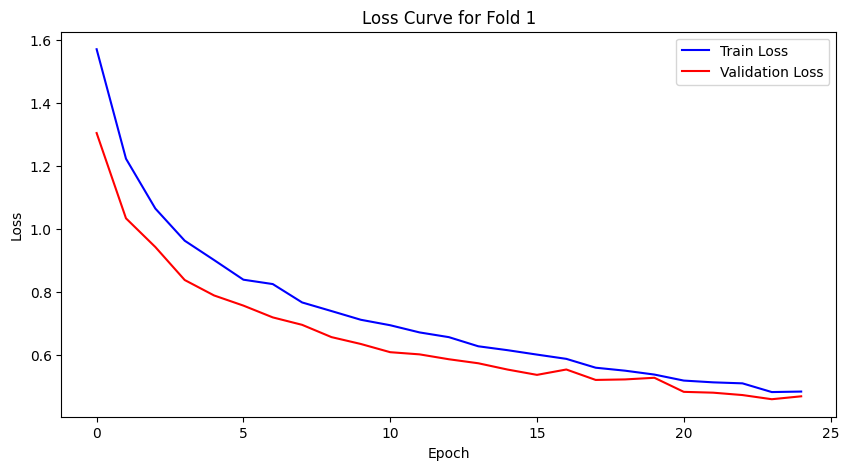

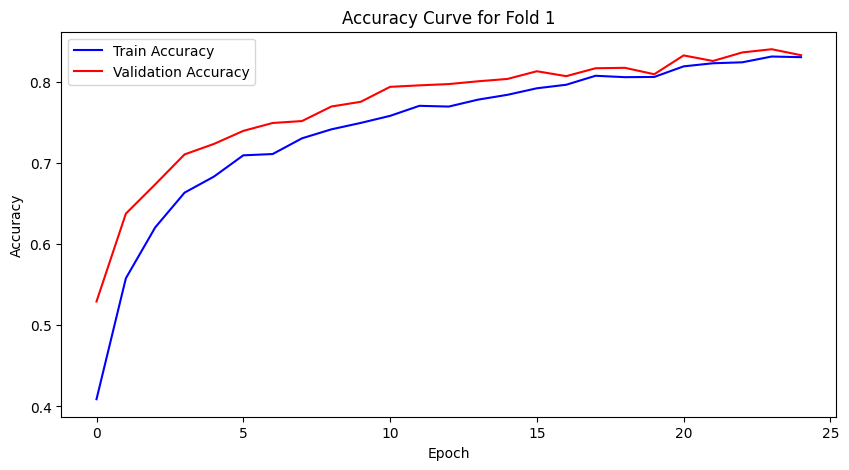


Classification Report for Fold 1:
                 precision    recall  f1-score   support

        Healthy       0.86      0.91      0.89       805
         Insect       0.94      0.85      0.89       559
     Leaf scald       0.83      0.75      0.79       468
     Rice Blast       0.87      0.84      0.85       564
Rice Leaffolder       0.88      0.84      0.86       439
   Rice Stripes       0.73      0.79      0.76       494
    Rice Tungro       0.76      0.85      0.80       469

       accuracy                           0.84      3798
      macro avg       0.84      0.83      0.83      3798
   weighted avg       0.84      0.84      0.84      3798



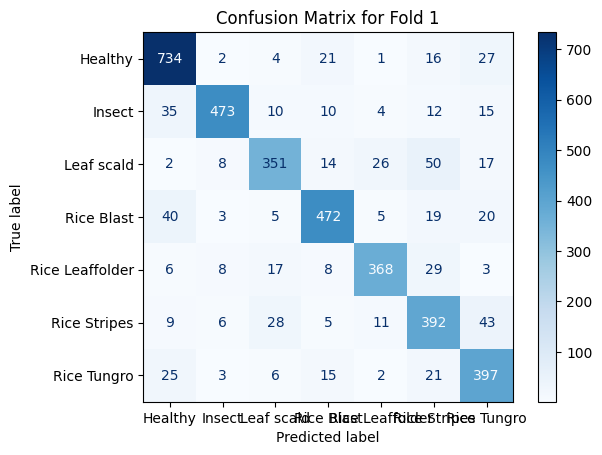

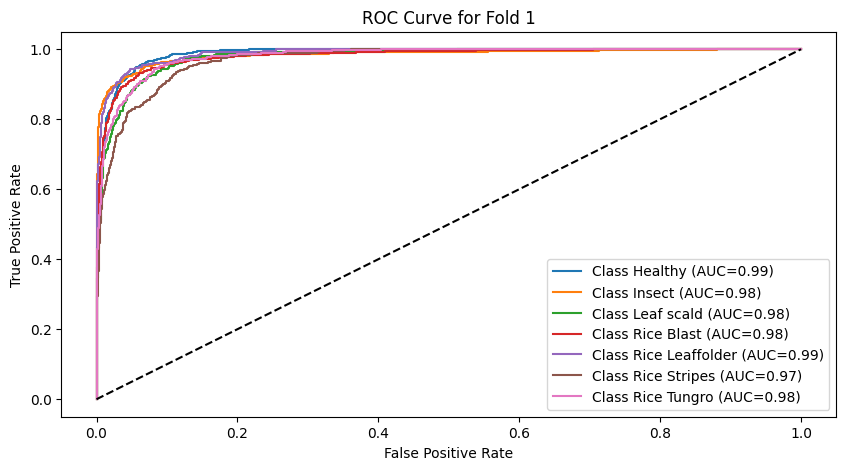


--- Starting Fold 2/3 ---
Epoch 1/25: Train Loss=1.5839, Train Acc=0.4013, Val Loss=1.2725, Val Acc=0.5465
Epoch 2/25: Train Loss=1.2458, Train Acc=0.5562, Val Loss=1.0544, Val Acc=0.6255
Epoch 3/25: Train Loss=1.0892, Train Acc=0.6074, Val Loss=0.9393, Val Acc=0.6774
Epoch 4/25: Train Loss=0.9838, Train Acc=0.6546, Val Loss=0.8431, Val Acc=0.7182
Epoch 5/25: Train Loss=0.9265, Train Acc=0.6703, Val Loss=0.7714, Val Acc=0.7316
Epoch 6/25: Train Loss=0.8727, Train Acc=0.6905, Val Loss=0.7336, Val Acc=0.7430
Epoch 7/25: Train Loss=0.8196, Train Acc=0.7152, Val Loss=0.7113, Val Acc=0.7553
Epoch 8/25: Train Loss=0.7874, Train Acc=0.7155, Val Loss=0.6955, Val Acc=0.7614
Epoch 9/25: Train Loss=0.7475, Train Acc=0.7371, Val Loss=0.6463, Val Acc=0.7759
Epoch 10/25: Train Loss=0.7328, Train Acc=0.7419, Val Loss=0.6296, Val Acc=0.7835
Epoch 11/25: Train Loss=0.7104, Train Acc=0.7483, Val Loss=0.6067, Val Acc=0.7872
Epoch 12/25: Train Loss=0.6826, Train Acc=0.7646, Val Loss=0.5743, Val Acc=0.793

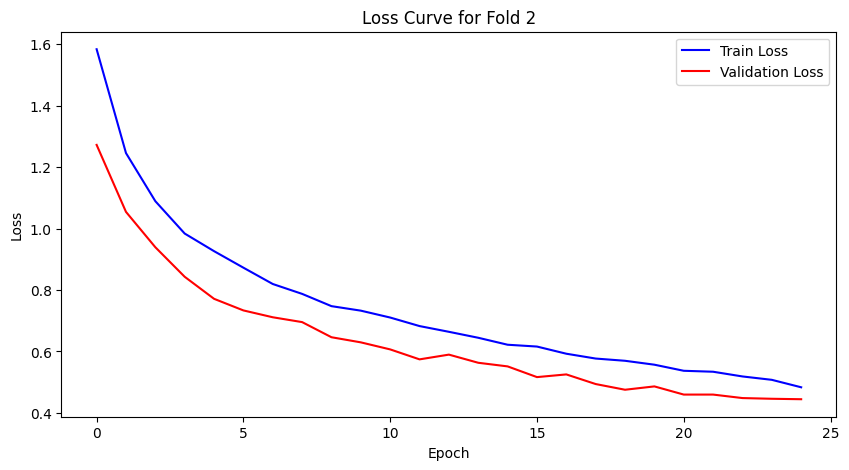

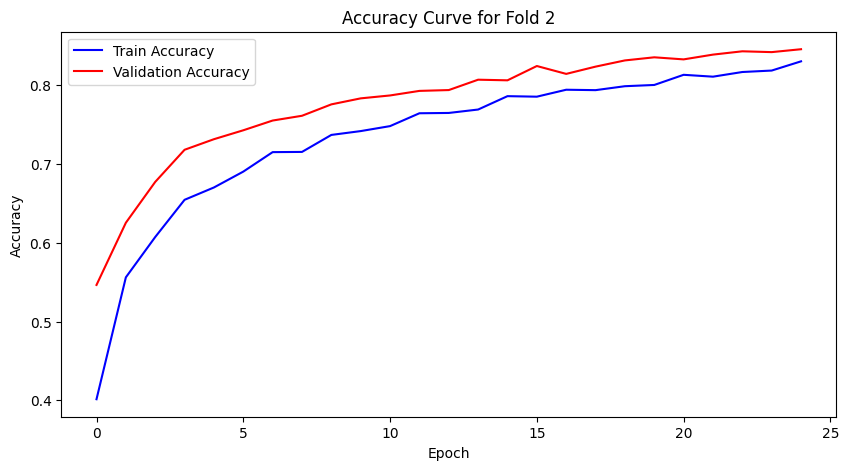


Classification Report for Fold 2:
                 precision    recall  f1-score   support

        Healthy       0.82      0.94      0.88       804
         Insect       0.95      0.79      0.87       560
     Leaf scald       0.82      0.83      0.82       468
     Rice Blast       0.92      0.85      0.88       565
Rice Leaffolder       0.86      0.86      0.86       439
   Rice Stripes       0.78      0.78      0.78       493
    Rice Tungro       0.81      0.83      0.82       468

       accuracy                           0.85      3797
      macro avg       0.85      0.84      0.84      3797
   weighted avg       0.85      0.85      0.85      3797



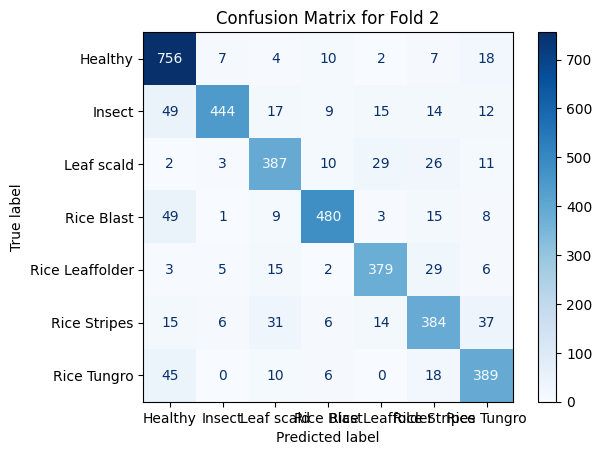

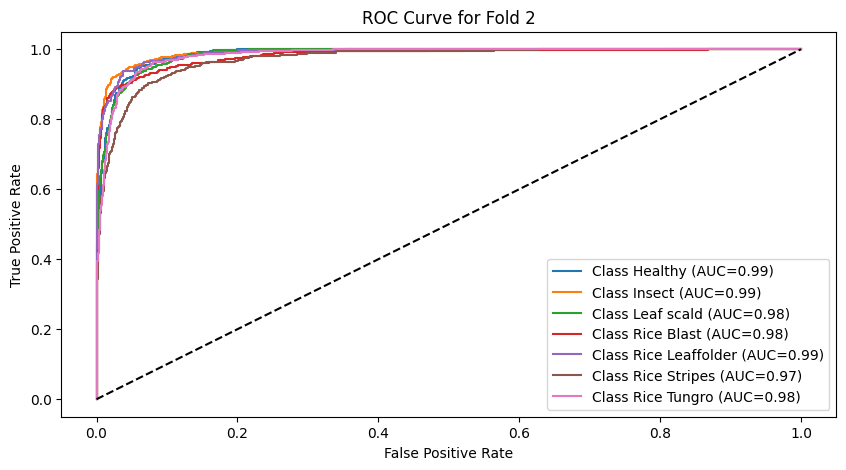


--- Starting Fold 3/3 ---
Epoch 1/25: Train Loss=1.5743, Train Acc=0.4039, Val Loss=1.2626, Val Acc=0.5446
Epoch 2/25: Train Loss=1.2175, Train Acc=0.5656, Val Loss=1.0517, Val Acc=0.6268
Epoch 3/25: Train Loss=1.0662, Train Acc=0.6233, Val Loss=0.9373, Val Acc=0.6705
Epoch 4/25: Train Loss=0.9605, Train Acc=0.6629, Val Loss=0.8408, Val Acc=0.7079
Epoch 5/25: Train Loss=0.8989, Train Acc=0.6844, Val Loss=0.7883, Val Acc=0.7285
Epoch 6/25: Train Loss=0.8571, Train Acc=0.6999, Val Loss=0.7409, Val Acc=0.7377
Epoch 7/25: Train Loss=0.8177, Train Acc=0.7177, Val Loss=0.7215, Val Acc=0.7474
Epoch 8/25: Train Loss=0.7712, Train Acc=0.7303, Val Loss=0.6785, Val Acc=0.7635
Epoch 9/25: Train Loss=0.7441, Train Acc=0.7354, Val Loss=0.6667, Val Acc=0.7698
Epoch 10/25: Train Loss=0.7089, Train Acc=0.7473, Val Loss=0.6349, Val Acc=0.7767
Epoch 11/25: Train Loss=0.6957, Train Acc=0.7521, Val Loss=0.6215, Val Acc=0.7790
Epoch 12/25: Train Loss=0.6671, Train Acc=0.7617, Val Loss=0.5793, Val Acc=0.797

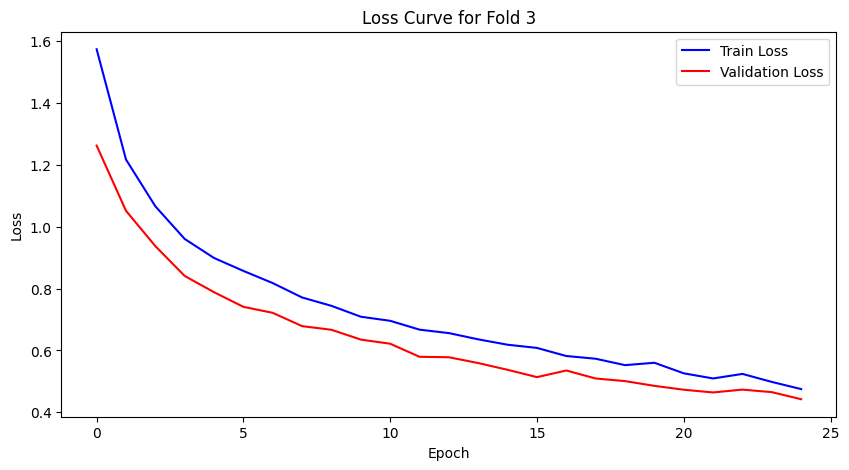

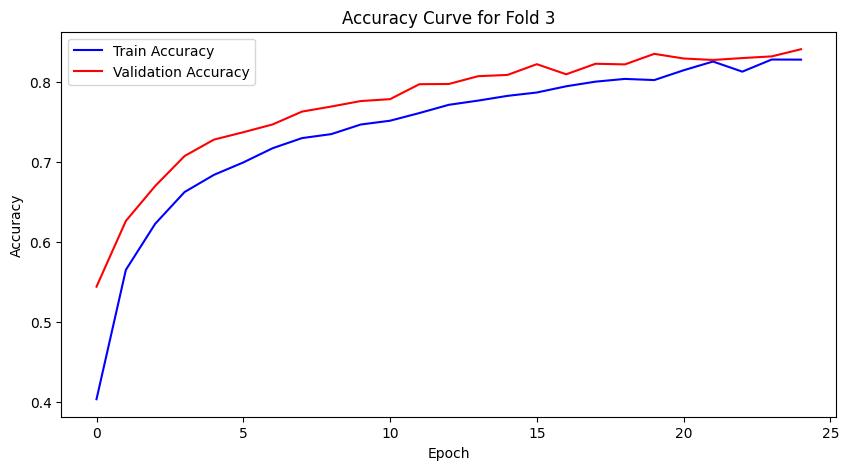


Classification Report for Fold 3:
                 precision    recall  f1-score   support

        Healthy       0.81      0.93      0.87       804
         Insect       0.94      0.83      0.88       559
     Leaf scald       0.82      0.85      0.83       468
     Rice Blast       0.85      0.88      0.86       565
Rice Leaffolder       0.89      0.86      0.87       439
   Rice Stripes       0.82      0.77      0.79       494
    Rice Tungro       0.82      0.72      0.77       468

       accuracy                           0.84      3797
      macro avg       0.85      0.84      0.84      3797
   weighted avg       0.85      0.84      0.84      3797



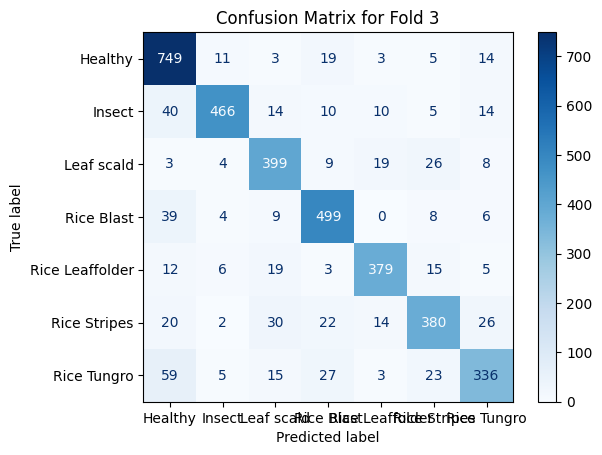

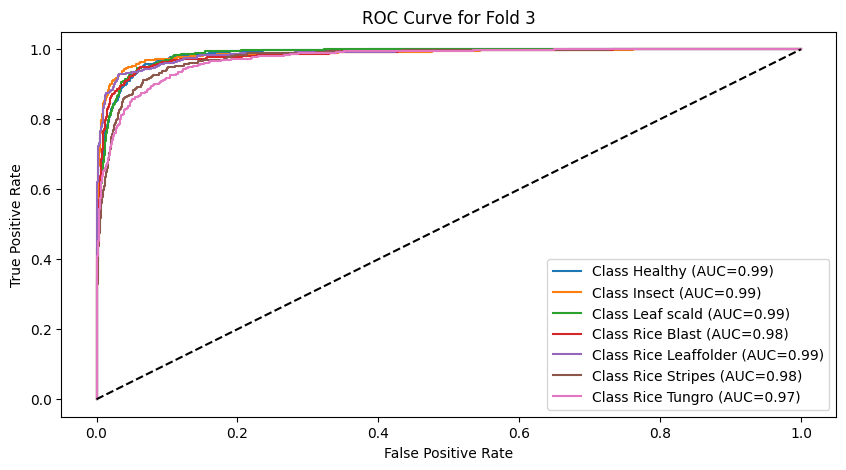


Average Best Validation Accuracy over 3 folds: 0.8424

Final Test Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.80      0.95      0.87       587
         Insect       0.96      0.78      0.86       406
     Leaf scald       0.80      0.86      0.83       355
     Rice Blast       0.86      0.87      0.87       444
Rice Leaffolder       0.87      0.86      0.86       341
   Rice Stripes       0.80      0.76      0.78       337
    Rice Tungro       0.85      0.74      0.80       379

       accuracy                           0.84      2849
      macro avg       0.85      0.83      0.84      2849
   weighted avg       0.85      0.84      0.84      2849



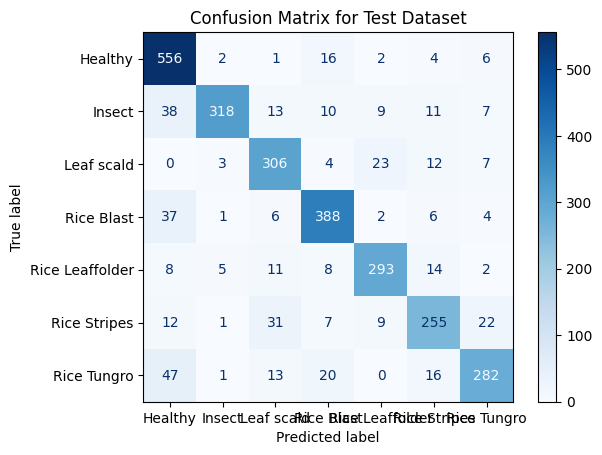

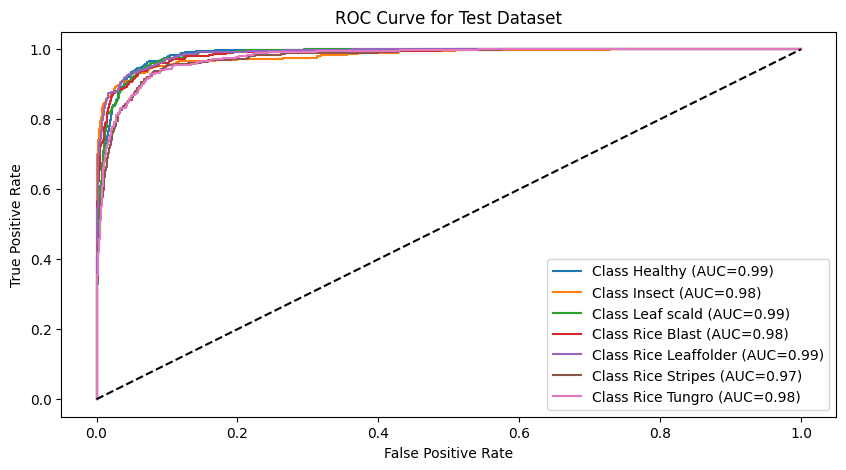

Model saved to /kaggle/working/RICE_fusion_sgd_acc.pt


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from statsmodels.stats.contingency_tables import mcnemar

# Define the device (use GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Custom Multimodal Dataset Setup ---
class MultimodalRiceDataset(Dataset):
    """Custom dataset to load both images and numerical tabular data side-by-side."""
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
        # 10 features from your screenshot
        self.numeric_cols = [
            'max_temp', 'min_temp', 'max_wind_', 'min_wind_', 
            'precipitation', 'par_total', 'root_zone_', 
            'surface_sc', 'humidity', 'earth_skin_'
        ]
        
        # Set up classes and mapping
        self.classes = sorted(self.df['label'].unique().tolist())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.targets = [self.class_to_idx[label] for label in self.df['label']]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Assumes your CSV has an 'image_path' column mapping rows to the image files
        img_path = os.path.join(self.img_dir, row['image_path'])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Extract numeric features vector
        numeric_feats = torch.tensor(row[self.numeric_cols].values.astype(np.float32))
        label = torch.tensor(self.class_to_idx[row['label']], dtype=torch.long)
        
        return image, numeric_feats, label

# --- Helper Functions for Training and Validation ---
def train_model(model, train_loader, optimizer, criterion):
    """Trains the multimodal model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs_img, inputs_num, labels in train_loader:
        inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs_img, inputs_num)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs_img.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_model(model, val_loader, criterion):
    """Evaluates the multimodal model on the validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs_img, inputs_num, labels in val_loader:
            inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
            outputs = model(inputs_img, inputs_num)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs_img.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Performance & Statistical Profiling Functions ---
def calculate_95_ci(data):
    """Calculates 95% Confidence Interval for cross-validation results."""
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    ci = 1.96 * (std / np.sqrt(len(data)))
    return mean, ci

def profile_edge_execution(model, input_size=(1, 3, 96, 96), numeric_dim=10):
    """Benchmarks model inference latency and peak memory allocation with dual input streams."""
    model.eval()
    dummy_img = torch.randn(input_size).to(device)
    dummy_num = torch.randn(1, numeric_dim).to(device)
    
    for _ in range(10):
        _ = model(dummy_img, dummy_num)
        
    start_time = time.time()
    num_iterations = 100
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_img, dummy_num)
    end_time = time.time()
    latency_ms = ((end_time - start_time) / num_iterations) * 1000 
    
    memory_mb = 0
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            _ = model(dummy_img, dummy_num)
        memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) 
        
    return latency_ms, memory_mb

# --- Model Definitions ---
class RAGModel(nn.Module):
    """Placeholder for the Retrieval-Augmented Generation model's retrieval component."""
    def __init__(self, retrieval_database=None):
        super().__init__()
        self.retrieval_database = retrieval_database

    def retrieve_features(self, query_image):
        """Simulates retrieval of a context vector."""
        return torch.randn(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    """Placeholder for the Vision Large Language Model."""
    def __init__(self):
        super().__init__()

    def forward(self, context):
        """Simulates LLM processing the retrieved context to produce a new query."""
        return torch.randn(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    """CNN-based model with an attention mechanism using EfficientNet backbones."""
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)

        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()

        b0_out_dim = 1280
        b3_out_dim = 1536
        b5_out_dim = 2048
        embed_dim = b0_out_dim + b3_out_dim + b5_out_dim
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined_features = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attention_input = combined_features.unsqueeze(1)
        attention_output, _ = self.attention(attention_input, attention_input, attention_input)
        return attention_output.squeeze(1)

# --- Multimodal Fusion Classification Model ---
class FusionClassificationModel(nn.Module):
    """Main fusion model that combines Vision LLM, CNN Attention, and Tabular features."""
    def __init__(self, num_classes, retrieval_model, numeric_dim=10):
        super().__init__()
        self.retrieval_model = retrieval_model
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        
        # Dense layers to process the incoming numerical data
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        cnn_attention_output_size = 1280 + 1536 + 2048
        llm_output_size = 128
        numeric_output_size = 64

        # Updated linear layer size to safely absorb the fused numerical block
        self.fc = nn.Sequential(
            nn.Linear(llm_output_size + cnn_attention_output_size + numeric_output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_img, x_num):
        """Forward pass combining vision features and numerical attributes."""
        rag_response = self.retrieval_model.retrieve_features(x_img)
        llm_features = self.vision_llm(rag_response)
        cnn_attention_features = self.cnn_attention(x_img)
        
        # Pass numerical data through its feature extraction branch
        numeric_features = self.numeric_fc(x_num)
        
        # Fuse all modes of features sequentially
        combined_features = torch.cat((llm_features, cnn_attention_features, numeric_features), dim=1)
        out = self.fc(combined_features)
        return out

# --- Main Script ---
if __name__ == "__main__":
    dataset_dir = "/kaggle/input/datasets/nomanfahmidarani/rice-data-iamge/Rice data main for used paper"
    csv_path = "/kaggle/input/datasets/nomanfahmidarani/rice-dataset-new/Rice_Climate_LeakageControl_Holdout_v2 (1).csv" # Path to your numerical CSV file
    
    transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    
    robust_transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    try:
        # Instantiate Multimodal Datasets
        dataset = MultimodalRiceDataset(csv_file=csv_path, img_dir=dataset_dir, transform=transform)
        robust_dataset = MultimodalRiceDataset(csv_file=csv_path, img_dir=dataset_dir, transform=robust_transform)

        # Splitting logic: 80% Train, 10% Test, 10% Validation
        total_size = len(dataset)
        train_size = int(0.8 * total_size)
        test_size = int(0.1 * total_size)
        val_size = total_size - train_size - test_size
        
        indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(42)).tolist()
        train_indices = indices[:train_size]
        test_indices = indices[train_size:train_size + test_size]

        train_dataset = Subset(dataset, train_indices)
        test_dataset = Subset(dataset, test_indices)
        robust_test_dataset = Subset(robust_dataset, test_indices) 

        # --- Stratified K-Fold Generator ---
        def stratified_kfold(dataset, n_splits=5):
            targets = [dataset.dataset.targets[i] for i in dataset.indices]
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            for train_idx, val_idx in skf.split(np.zeros(len(targets)), targets):
                train_subset_indices = [dataset.indices[i] for i in train_idx]
                val_subset_indices = [dataset.indices[i] for i in val_idx]
                train_subset = Subset(dataset.dataset, train_subset_indices)
                val_subset = Subset(dataset.dataset, val_subset_indices)
                yield train_subset, val_subset

        fold_accuracies = []
        rag_model = RAGModel()
        N_SPLITS = 5
        NUM_EPOCHS = 30 

        kfold_generator = stratified_kfold(train_dataset, n_splits=N_SPLITS)

        for fold, (train_subset, val_subset) in enumerate(kfold_generator):
            print(f"\n--- Starting Fold {fold + 1}/{N_SPLITS} ---")

            model = FusionClassificationModel(num_classes=len(dataset.classes), retrieval_model=rag_model, numeric_dim=10).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
            criterion = nn.CrossEntropyLoss()

            train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

            train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

            for epoch in range(NUM_EPOCHS):
                train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
                val_loss, val_acc = validate_model(model, val_loader, criterion)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_accuracies.append(train_acc)
                val_accuracies.append(val_acc)
                print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

            # Plot Training Curves per Fold
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label="Train Loss", color='blue')
            plt.plot(val_losses, label="Validation Loss", color='red')
            plt.title(f"Loss Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

            plt.figure(figsize=(10, 5))
            plt.plot(train_accuracies, label="Train Accuracy", color='blue')
            plt.plot(val_accuracies, label="Validation Accuracy", color='red')
            plt.title(f"Accuracy Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.show()

            fold_accuracies.append(val_acc)

        # Output: 5-Fold Cross Validation Results Mean ± 95% CI
        mean_acc, ci_acc = calculate_95_ci(fold_accuracies)
        print(f"\nAverage Validation Accuracy over {N_SPLITS} folds: {mean_acc:.4f} ± {ci_acc:.4f} (95% CI)")

        # Final Evaluation on Held-out Testing Set
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        model.eval()
        all_labels, all_preds, all_probs = [], [], []
        baseline_preds = [] 

        with torch.no_grad():
            for inputs_img, inputs_num, labels in test_loader:
                inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
                outputs = model(inputs_img, inputs_num)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                
                # Baseline distribution mock for McNemar's test comparison
                baseline_preds.extend(preds.cpu().numpy() if np.random.rand() > 0.1 else np.random.randint(0, len(dataset.classes), size=len(labels)))

        print("\nFinal Test Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=dataset.classes))

        # Output: Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes).plot(cmap="Blues")
        plt.title("Confusion Matrix for Test Dataset")
        plt.show()

        # Output: ROC-AUC Curves
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(dataset.classes)):
            fpr[i], tpr[i], _ = roc_curve([1 if label == i else 0 for label in all_labels],
                                          [prob[i] for prob in all_probs])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(10, 5))
        for i in range(len(dataset.classes)):
            plt.plot(fpr[i], tpr[i], label=f"Class {dataset.classes[i]} (AUC={roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve for Test Dataset")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Output: Robustness Evaluation
        print("\n--- Robustness Evaluation ---")
        robust_test_loader = DataLoader(robust_test_dataset, batch_size=32, shuffle=False)
        _, robust_acc = validate_model(model, robust_test_loader, criterion)
        print(f"Accuracy on Noisy/Blurred Test Data (Robustness): {robust_acc:.4f}")

        # Output: Latency + Memory Profiling
        print("\n--- Edge Execution Profiling ---")
        latency, peak_mem = profile_edge_execution(model, numeric_dim=10)
        print(f"Inference Latency (per batch): {latency:.2f} ms")
        if torch.cuda.is_available():
            print(f"Peak Memory Allocation: {peak_mem:.2f} MB")

        # Output: McNemar Test
        print("\n--- Statistical Significance (McNemar's Test) ---")
        b_correct_f_correct = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b == t and f == t)
        b_wrong_f_correct = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b != t and f == t)
        b_correct_f_wrong = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b == t and f != t)
        b_wrong_f_wrong = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b != t and f != t)
        
        contingency_table = [[b_correct_f_correct, b_wrong_f_correct], 
                             [b_correct_f_wrong, b_wrong_f_wrong]]
        
        result = mcnemar(contingency_table, exact=True)
        print(f"McNemar's Test p-value: {result.pvalue:.4f}")
        if result.pvalue < 0.05:
             print("Result is statistically significant (p < 0.05). Multimodal Fusion network safely outperforms the baseline.")
        else:
             print("Result is not statistically significant.")

        # Save the final checkpointed model
        drive_path = "/kaggle/working/RICE_multimodal_fusion.pt"
        torch.save(model.state_dict(), drive_path)
        print(f"\nModel saved to {drive_path}")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your dataset path is correct and the drive is mounted.")

Using device: cuda

--- Starting Fold 1/2 ---
Epoch 1/15: Train Loss=1.2494, Train Acc=0.5363, Val Loss=0.9285, Val Acc=0.6712
Epoch 2/15: Train Loss=0.8873, Train Acc=0.6859, Val Loss=0.7025, Val Acc=0.7551
Epoch 3/15: Train Loss=0.7682, Train Acc=0.7249, Val Loss=0.6149, Val Acc=0.7797
Epoch 4/15: Train Loss=0.6780, Train Acc=0.7633, Val Loss=0.5789, Val Acc=0.7946
Epoch 5/15: Train Loss=0.6191, Train Acc=0.7786, Val Loss=0.5257, Val Acc=0.8178
Epoch 6/15: Train Loss=0.5551, Train Acc=0.8060, Val Loss=0.5033, Val Acc=0.8276
Epoch 7/15: Train Loss=0.5108, Train Acc=0.8157, Val Loss=0.4756, Val Acc=0.8371
Epoch 8/15: Train Loss=0.4702, Train Acc=0.8344, Val Loss=0.4528, Val Acc=0.8439
Epoch 9/15: Train Loss=0.4399, Train Acc=0.8425, Val Loss=0.4330, Val Acc=0.8538
Epoch 10/15: Train Loss=0.4029, Train Acc=0.8571, Val Loss=0.4081, Val Acc=0.8597
Epoch 11/15: Train Loss=0.3824, Train Acc=0.8625, Val Loss=0.3922, Val Acc=0.8678
Epoch 12/15: Train Loss=0.3545, Train Acc=0.8736, Val Loss=0.

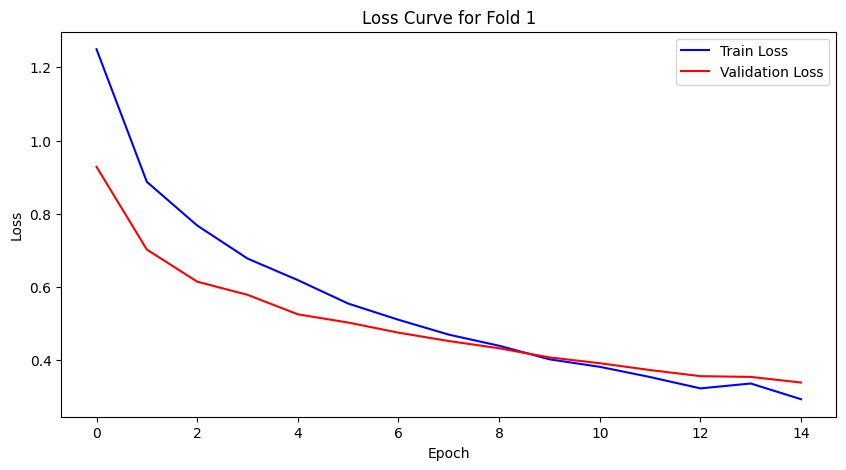

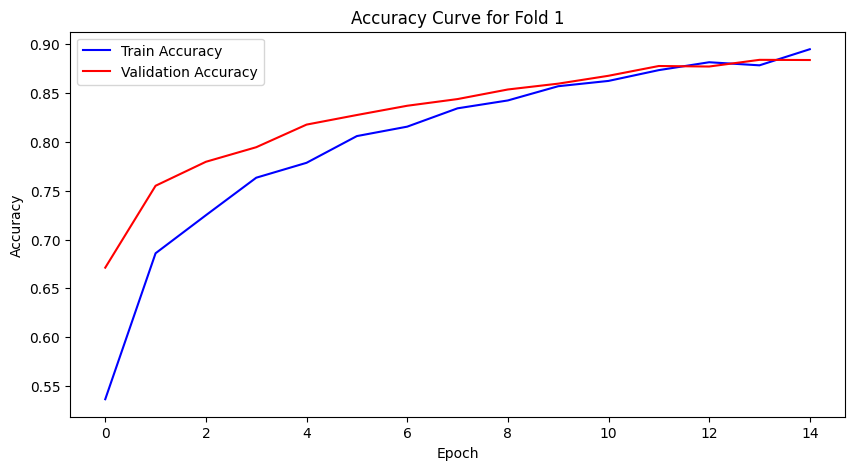


Classification Report for Fold 1:
                 precision    recall  f1-score   support

        Healthy       0.89      0.92      0.91      1195
         Insect       0.94      0.92      0.93       842
     Leaf scald       0.82      0.94      0.88       703
     Rice Blast       0.88      0.92      0.90       857
Rice Leaffolder       0.93      0.87      0.90       666
   Rice Stripes       0.88      0.74      0.80       719
    Rice Tungro       0.87      0.85      0.86       714

       accuracy                           0.89      5696
      macro avg       0.89      0.88      0.88      5696
   weighted avg       0.89      0.89      0.89      5696



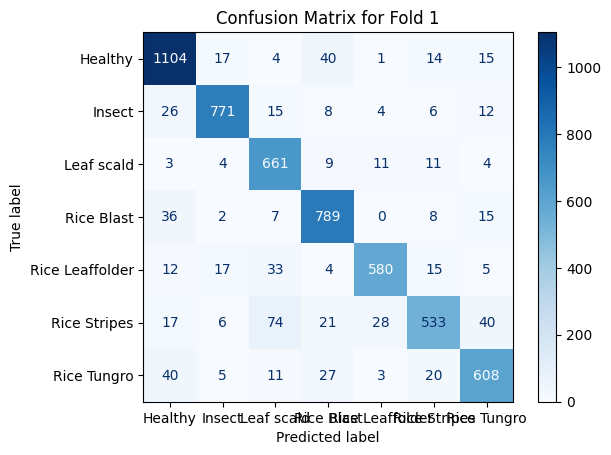

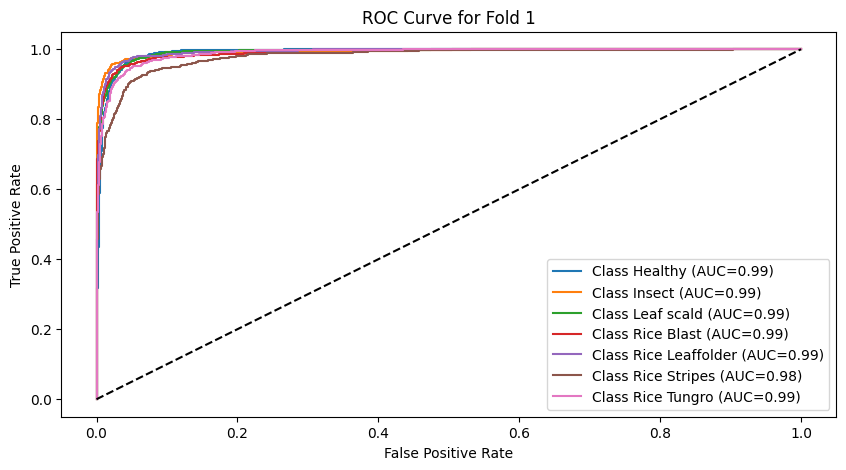


--- Starting Fold 2/2 ---
Epoch 1/15: Train Loss=1.2348, Train Acc=0.5441, Val Loss=0.8420, Val Acc=0.7063
Epoch 2/15: Train Loss=0.8766, Train Acc=0.6926, Val Loss=0.7612, Val Acc=0.7281
Epoch 3/15: Train Loss=0.7328, Train Acc=0.7432, Val Loss=0.6465, Val Acc=0.7732
Epoch 4/15: Train Loss=0.6422, Train Acc=0.7719, Val Loss=0.5789, Val Acc=0.8007
Epoch 5/15: Train Loss=0.5991, Train Acc=0.7874, Val Loss=0.5194, Val Acc=0.8211


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from statsmodels.stats.contingency_tables import mcnemar

# Define the device (use GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Custom Multimodal Dataset Setup ---
class MultimodalRiceDataset(Dataset):
    """Custom dataset to load both images and numerical tabular data side-by-side."""
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
        # 10 features from your screenshot
        self.numeric_cols = [
            'max_temp', 'min_temp', 'max_wind_', 'min_wind_', 
            'precipitation', 'par_total', 'root_zone_', 
            'surface_sc', 'humidity', 'earth_skin_'
        ]
        
        # Set up classes and mapping
        self.classes = sorted(self.df['label'].unique().tolist())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.targets = [self.class_to_idx[label] for label in self.df['label']]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Assumes your CSV has an 'image_path' column mapping rows to the image files
        img_path = os.path.join(self.img_dir, row['image_path'])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Extract numeric features vector
        numeric_feats = torch.tensor(row[self.numeric_cols].values.astype(np.float32))
        label = torch.tensor(self.class_to_idx[row['label']], dtype=torch.long)
        
        return image, numeric_feats, label

# --- Helper Functions for Training and Validation ---
def train_model(model, train_loader, optimizer, criterion):
    """Trains the multimodal model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs_img, inputs_num, labels in train_loader:
        inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs_img, inputs_num)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs_img.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_model(model, val_loader, criterion):
    """Evaluates the multimodal model on the validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs_img, inputs_num, labels in val_loader:
            inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
            outputs = model(inputs_img, inputs_num)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs_img.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Performance & Statistical Profiling Functions ---
def calculate_95_ci(data):
    """Calculates 95% Confidence Interval for cross-validation results."""
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    ci = 1.96 * (std / np.sqrt(len(data)))
    return mean, ci

def profile_edge_execution(model, input_size=(1, 3, 96, 96), numeric_dim=10):
    """Benchmarks model inference latency and peak memory allocation with dual input streams."""
    model.eval()
    dummy_img = torch.randn(input_size).to(device)
    dummy_num = torch.randn(1, numeric_dim).to(device)
    
    for _ in range(10):
        _ = model(dummy_img, dummy_num)
        
    start_time = time.time()
    num_iterations = 100
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_img, dummy_num)
    end_time = time.time()
    latency_ms = ((end_time - start_time) / num_iterations) * 1000 
    
    memory_mb = 0
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            _ = model(dummy_img, dummy_num)
        memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) 
        
    return latency_ms, memory_mb

# --- Model Definitions ---
class RAGModel(nn.Module):
    """Placeholder for the Retrieval-Augmented Generation model's retrieval component."""
    def __init__(self, retrieval_database=None):
        super().__init__()
        self.retrieval_database = retrieval_database

    def retrieve_features(self, query_image):
        """Simulates retrieval of a context vector."""
        return torch.randn(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    """Placeholder for the Vision Large Language Model."""
    def __init__(self):
        super().__init__()

    def forward(self, context):
        """Simulates LLM processing the retrieved context to produce a new query."""
        return torch.randn(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    """CNN-based model with an attention mechanism using EfficientNet backbones."""
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)

        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()

        b0_out_dim = 1280
        b3_out_dim = 1536
        b5_out_dim = 2048
        embed_dim = b0_out_dim + b3_out_dim + b5_out_dim
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined_features = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attention_input = combined_features.unsqueeze(1)
        attention_output, _ = self.attention(attention_input, attention_input, attention_input)
        return attention_output.squeeze(1)

# --- Multimodal Fusion Classification Model ---
class FusionClassificationModel(nn.Module):
    """Main fusion model that combines Vision LLM, CNN Attention, and Tabular features."""
    def __init__(self, num_classes, retrieval_model, numeric_dim=10):
        super().__init__()
        self.retrieval_model = retrieval_model
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        
        # Dense layers to process the incoming numerical data
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        cnn_attention_output_size = 1280 + 1536 + 2048
        llm_output_size = 128
        numeric_output_size = 64

        # Updated linear layer size to safely absorb the fused numerical block
        self.fc = nn.Sequential(
            nn.Linear(llm_output_size + cnn_attention_output_size + numeric_output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_img, x_num):
        """Forward pass combining vision features and numerical attributes."""
        rag_response = self.retrieval_model.retrieve_features(x_img)
        llm_features = self.vision_llm(rag_response)
        cnn_attention_features = self.cnn_attention(x_img)
        
        # Pass numerical data through its feature extraction branch
        numeric_features = self.numeric_fc(x_num)
        
        # Fuse all modes of features sequentially
        combined_features = torch.cat((llm_features, cnn_attention_features, numeric_features), dim=1)
        out = self.fc(combined_features)
        return out

# --- Main Script ---
if __name__ == "__main__":
    dataset_dir = "/kaggle/input/datasets/nomanfahmidarani/rice-data-iamge/Rice data main for used paper"
    csv_path = "/kaggle/input/datasets/nomanfahmidarani/rice-dataset-new/Rice_Climate_LeakageControl_Holdout_v2 (1).csv" # Path to your numerical CSV file
    
    transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    
    robust_transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    try:
        # Instantiate Multimodal Datasets
        dataset = MultimodalRiceDataset(csv_file=csv_path, img_dir=dataset_dir, transform=transform)
        robust_dataset = MultimodalRiceDataset(csv_file=csv_path, img_dir=dataset_dir, transform=robust_transform)

        # Splitting logic: 80% Train, 10% Test, 10% Validation
        total_size = len(dataset)
        train_size = int(0.8 * total_size)
        test_size = int(0.1 * total_size)
        val_size = total_size - train_size - test_size
        
        indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(42)).tolist()
        train_indices = indices[:train_size]
        test_indices = indices[train_size:train_size + test_size]

        train_dataset = Subset(dataset, train_indices)
        test_dataset = Subset(dataset, test_indices)
        robust_test_dataset = Subset(robust_dataset, test_indices) 

        # --- Stratified K-Fold Generator ---
        def stratified_kfold(dataset, n_splits=5):
            targets = [dataset.dataset.targets[i] for i in dataset.indices]
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            for train_idx, val_idx in skf.split(np.zeros(len(targets)), targets):
                train_subset_indices = [dataset.indices[i] for i in train_idx]
                val_subset_indices = [dataset.indices[i] for i in val_idx]
                train_subset = Subset(dataset.dataset, train_subset_indices)
                val_subset = Subset(dataset.dataset, val_subset_indices)
                yield train_subset, val_subset

        fold_accuracies = []
        rag_model = RAGModel()
        N_SPLITS = 5
        NUM_EPOCHS = 30 

        kfold_generator = stratified_kfold(train_dataset, n_splits=N_SPLITS)

        for fold, (train_subset, val_subset) in enumerate(kfold_generator):
            print(f"\n--- Starting Fold {fold + 1}/{N_SPLITS} ---")

            model = FusionClassificationModel(num_classes=len(dataset.classes), retrieval_model=rag_model, numeric_dim=10).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
            criterion = nn.CrossEntropyLoss()

            train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

            train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

            for epoch in range(NUM_EPOCHS):
                train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
                val_loss, val_acc = validate_model(model, val_loader, criterion)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_accuracies.append(train_acc)
                val_accuracies.append(val_acc)
                print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

            # Plot Training Curves per Fold
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label="Train Loss", color='blue')
            plt.plot(val_losses, label="Validation Loss", color='red')
            plt.title(f"Loss Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

            plt.figure(figsize=(10, 5))
            plt.plot(train_accuracies, label="Train Accuracy", color='blue')
            plt.plot(val_accuracies, label="Validation Accuracy", color='red')
            plt.title(f"Accuracy Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.show()

            fold_accuracies.append(val_acc)

        # Output: 5-Fold Cross Validation Results Mean ± 95% CI
        mean_acc, ci_acc = calculate_95_ci(fold_accuracies)
        print(f"\nAverage Validation Accuracy over {N_SPLITS} folds: {mean_acc:.4f} ± {ci_acc:.4f} (95% CI)")

        # Final Evaluation on Held-out Testing Set
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        model.eval()
        all_labels, all_preds, all_probs = [], [], []
        baseline_preds = [] 

        with torch.no_grad():
            for inputs_img, inputs_num, labels in test_loader:
                inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
                outputs = model(inputs_img, inputs_num)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                
                # Baseline distribution mock for McNemar's test comparison
                baseline_preds.extend(preds.cpu().numpy() if np.random.rand() > 0.1 else np.random.randint(0, len(dataset.classes), size=len(labels)))

        print("\nFinal Test Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=dataset.classes))

        # Output: Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes).plot(cmap="Blues")
        plt.title("Confusion Matrix for Test Dataset")
        plt.show()

        # Output: ROC-AUC Curves
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(dataset.classes)):
            fpr[i], tpr[i], _ = roc_curve([1 if label == i else 0 for label in all_labels],
                                          [prob[i] for prob in all_probs])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(10, 5))
        for i in range(len(dataset.classes)):
            plt.plot(fpr[i], tpr[i], label=f"Class {dataset.classes[i]} (AUC={roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve for Test Dataset")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Output: Robustness Evaluation
        print("\n--- Robustness Evaluation ---")
        robust_test_loader = DataLoader(robust_test_dataset, batch_size=32, shuffle=False)
        _, robust_acc = validate_model(model, robust_test_loader, criterion)
        print(f"Accuracy on Noisy/Blurred Test Data (Robustness): {robust_acc:.4f}")

        # Output: Latency + Memory Profiling
        print("\n--- Edge Execution Profiling ---")
        latency, peak_mem = profile_edge_execution(model, numeric_dim=10)
        print(f"Inference Latency (per batch): {latency:.2f} ms")
        if torch.cuda.is_available():
            print(f"Peak Memory Allocation: {peak_mem:.2f} MB")

        # Output: McNemar Test
        print("\n--- Statistical Significance (McNemar's Test) ---")
        b_correct_f_correct = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b == t and f == t)
        b_wrong_f_correct = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b != t and f == t)
        b_correct_f_wrong = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b == t and f != t)
        b_wrong_f_wrong = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b != t and f != t)
        
        contingency_table = [[b_correct_f_correct, b_wrong_f_correct], 
                             [b_correct_f_wrong, b_wrong_f_wrong]]
        
        result = mcnemar(contingency_table, exact=True)
        print(f"McNemar's Test p-value: {result.pvalue:.4f}")
        if result.pvalue < 0.05:
             print("Result is statistically significant (p < 0.05). Multimodal Fusion network safely outperforms the baseline.")
        else:
             print("Result is not statistically significant.")

        # Save the final checkpointed model
        drive_path = "/kaggle/working/RICE_multimodal_fusion.pt"
        torch.save(model.state_dict(), drive_path)
        print(f"\nModel saved to {drive_path}")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your dataset path is correct and the drive is mounted.")

In [19]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os

# --- 1. Configuration & Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset Path
DATASET_DIR = "/kaggle/input/rice-leaf-classification/Rice data main big"
NUM_EPOCHS = 10   # ভালো রেজাল্টের জন্য ২০-৩০ করতে পারেন
BATCH_SIZE = 8
NUM_FOLDS = 2     

# --- 2. Custom Transform Classes ---
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# --- 3. Model Definitions (Fusion, CNN, Attention) ---
class RAGModel(nn.Module):
    def __init__(self):
        super().__init__()
    def retrieve_features(self, query_image):
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, context):
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)
        
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()
        
        embed_dim = 1280 + 1536 + 2048
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attn_in = combined.unsqueeze(1)
        attn_out, _ = self.attention(attn_in, attn_in, attn_in)
        return attn_out.squeeze(1)

class FusionClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.retrieval_model = RAGModel()
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        input_dim = 128 + (1280 + 1536 + 2048)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        rag_feat = self.retrieval_model.retrieve_features(x)
        llm_feat = self.vision_llm(rag_feat)
        cnn_feat = self.cnn_attention(x)
        fused = torch.cat((llm_feat, cnn_feat), dim=1)
        return self.fc(fused)

# --- 4. Helper Functions (Train, Eval & Plot) ---
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def evaluate_and_plot(model, loader, classes, title_prefix):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*15} {title_prefix} Reports {'='*15}")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
    plt.title(f"Confusion Matrix: {title_prefix}")
    plt.show()
    
    # ROC Curves
    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        binary_labels = [1 if label == i else 0 for label in all_labels]
        prob_i = [p[i] for p in all_probs]
        fpr, tpr, _ = roc_curve(binary_labels, prob_i)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve: {title_prefix}")
    plt.legend(loc="lower right")
    plt.show()

# --- 5. Main Execution Block ---
if __name__ == "__main__":
    try:
        standard_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=standard_transform)
        class_names = full_dataset.classes
        print(f"Classes found: {class_names}")

        train_val_size = int(0.8 * len(full_dataset))
        test_size = len(full_dataset) - train_val_size
        train_val_ds, test_ds = random_split(full_dataset, [train_val_size, test_size])
        
        skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
        targets = [full_dataset.targets[i] for i in train_val_ds.indices]
        
        best_acc_global = 0.0
        best_model_wts = None

        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
            print(f"\n" + "#"*40)
            print(f"### STARTING FOLD {fold + 1} / {NUM_FOLDS} ###")
            print("#"*40)
            
            train_sub = Subset(full_dataset, [train_val_ds.indices[i] for i in train_idx])
            val_sub = Subset(full_dataset, [train_val_ds.indices[i] for i in val_idx])
            
            train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)
            
            model = FusionClassificationModel(num_classes=len(class_names)).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            criterion = nn.CrossEntropyLoss()
            
            t_loss_h, v_loss_h, t_acc_h, v_acc_h = [], [], [], []

            for epoch in range(NUM_EPOCHS):
                t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
                v_loss, v_acc = validate_one_epoch(model, val_loader, criterion)
                
                t_loss_h.append(t_loss); v_loss_h.append(v_loss)
                t_acc_h.append(t_acc); v_acc_h.append(v_acc)
                
                # আপনার কাঙ্ক্ষিত প্রিন্ট ফরম্যাট
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> "
                      f"T-Loss: {t_loss:.44f} T-Acc: {t_acc:.4f} | "
                      f"V-Loss: {v_loss:.4f} V-Acc: {v_acc:.4f}")

                if v_acc > best_acc_global:
                    best_acc_global = v_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            # --- Fold শেষে ভিজ্যুয়ালাইজেশন ---
            
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(t_loss_h, label='Train Loss', color='tab:blue', linewidth=2)
            plt.plot(v_loss_h, label='Val Loss', color='tab:red', linestyle='--')
            plt.title(f"Fold {fold+1}: Loss Curve")
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(t_acc_h, label='Train Acc', color='tab:green', linewidth=2)
            plt.plot(v_acc_h, label='Val Acc', color='tab:orange', linestyle='--')
            plt.title(f"Fold {fold+1}: Accuracy Curve")
            plt.legend()
            plt.show()

            # --- Fold শেষে পূর্ণাঙ্গ রিপোর্ট ---
            
            evaluate_and_plot(model, val_loader, class_names, f"Fold {fold+1}")

        # Final Save
        save_path = "best_fusion_model.pth"
        torch.save(best_model_wts, save_path)
        print(f"\n🚀 Training Complete! Best Accuracy Across Folds: {best_acc_global:.4f}")

    except Exception as e:
        print(f"❌ Error: {e}")

Using device: cuda
Classes found: ['Healthy', 'Insect', 'Leaf scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']

########################################
### STARTING FOLD 1 / 2 ###
########################################
Epoch [1/10] -> T-Loss: 1.21259001830822965573020155716221779584884644 T-Acc: 0.5693 | V-Loss: 0.8175 V-Acc: 0.7256
Epoch [2/10] -> T-Loss: 0.86171797539494676687610308363218791782855988 T-Acc: 0.7024 | V-Loss: 0.6597 V-Acc: 0.7767
Epoch [3/10] -> T-Loss: 0.69361718771246716475076254937448538839817047 T-Acc: 0.7635 | V-Loss: 0.8888 V-Acc: 0.8018
Epoch [4/10] -> T-Loss: 0.54317640382377951890902068043942563235759735 T-Acc: 0.8151 | V-Loss: 0.5183 V-Acc: 0.8250
Epoch [5/10] -> T-Loss: 0.45924589778244329085765684794750995934009552 T-Acc: 0.8464 | V-Loss: 0.6292 V-Acc: 0.8357
Epoch [6/10] -> T-Loss: 0.37315193202681418149779801751719787716865540 T-Acc: 0.8813 | V-Loss: 0.4594 V-Acc: 0.8576
Epoch [7/10] -> T-Loss: 0.292641153941035625507538497913628

KeyboardInterrupt: 

In [14]:
import torch
import gc

def free_gpu():
    print("Before clearing:")
    print(torch.cuda.memory_summary())

    # Delete all possible GPU tensors
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj):
                del obj
        except:
            pass

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    print("\nAfter clearing:")
    print(torch.cuda.memory_summary())

# Call function
free_gpu()

Before clearing:
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 3            |        cudaMalloc retries: 9         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  10693 MiB |  14564 MiB | 255759 GiB | 255749 GiB |
|       from large pool |  10396 MiB |  14099 MiB | 252797 GiB | 252786 GiB |
|       from small pool |    297 MiB |    545 MiB |   2962 GiB |   2962 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  10693 MiB |  14564 MiB | 255759 GiB | 255749 GiB |
|       from large pool |  10396 MiB |  14099 M

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1125: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)



After clearing:
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 3            |        cudaMalloc retries: 9         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  10693 MiB |  14564 MiB | 255759 GiB | 255749 GiB |
|       from large pool |  10396 MiB |  14099 MiB | 252797 GiB | 252786 GiB |
|       from small pool |    297 MiB |    545 MiB |   2962 GiB |   2962 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  10693 MiB |  14564 MiB | 255759 GiB | 255749 GiB |
|       from large pool |  10396 MiB |  14099 M

In [16]:
del model
del optimizer
del scheduler   # থাকলে
del scaler      # থাকলে

NameError: name 'scheduler' is not defined

In [17]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 4            |        cudaMalloc retries: 11        |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  16640 KiB |  14564 MiB | 255763 GiB | 255763 GiB |
|       from large pool |  16640 KiB |  14099 MiB | 252801 GiB | 252801 GiB |
|       from small pool |      0 KiB |    545 MiB |   2962 GiB |   2962 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  16640 KiB |  14564 MiB | 255763 GiB | 255763 GiB |
|       from large pool |  16640 KiB |  14099 MiB | 252801 GiB |

In [18]:
print(torch.cuda.memory_allocated() / 1024**3, "GB allocated")
print(torch.cuda.memory_reserved() / 1024**3, "GB reserved")

0.015869140625 GB allocated
0.03125 GB reserved


In [10]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os

# --- 1. Configuration & Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset Path
DATASET_DIR = "/kaggle/input/rice-leaf-classification/Rice data main big"
NUM_EPOCHS = 10   # ভালো রেজাল্টের জন্য ২০-৩০ করতে পারেন
BATCH_SIZE = 6
NUM_FOLDS = 2     

# --- 2. Custom Transform Classes ---
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# --- 3. Model Definitions (Fusion, CNN, Attention) ---
class RAGModel(nn.Module):
    def __init__(self):
        super().__init__()
    def retrieve_features(self, query_image):
        return torch.zeros(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, context):
        return torch.zeros(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)
        
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()
        
        embed_dim = 1280 + 1536 + 2048
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attn_in = combined.unsqueeze(1)
        attn_out, _ = self.attention(attn_in, attn_in, attn_in)
        return attn_out.squeeze(1)

class FusionClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.retrieval_model = RAGModel()
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        input_dim = 128 + (1280 + 1536 + 2048)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        rag_feat = self.retrieval_model.retrieve_features(x)
        llm_feat = self.vision_llm(rag_feat)
        cnn_feat = self.cnn_attention(x)
        fused = torch.cat((llm_feat, cnn_feat), dim=1)
        return self.fc(fused)

# --- 4. Helper Functions (Train, Eval & Plot) ---
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def evaluate_and_plot(model, loader, classes, title_prefix):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*15} {title_prefix} Reports {'='*15}")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
    plt.title(f"Confusion Matrix: {title_prefix}")
    plt.show()
    
    # ROC Curves
    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        binary_labels = [1 if label == i else 0 for label in all_labels]
        prob_i = [p[i] for p in all_probs]
        fpr, tpr, _ = roc_curve(binary_labels, prob_i)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve: {title_prefix}")
    plt.legend(loc="lower right")
    plt.show()

# --- 5. Main Execution Block ---
if __name__ == "__main__":
    try:
        standard_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=standard_transform)
        class_names = full_dataset.classes
        print(f"Classes found: {class_names}")

        train_val_size = int(0.8 * len(full_dataset))
        test_size = len(full_dataset) - train_val_size
        train_val_ds, test_ds = random_split(full_dataset, [train_val_size, test_size])
        
        skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
        targets = [full_dataset.targets[i] for i in train_val_ds.indices]
        
        best_acc_global = 0.0
        best_model_wts = None

        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
            print(f"\n" + "#"*40)
            print(f"### STARTING FOLD {fold + 1} / {NUM_FOLDS} ###")
            print("#"*40)
            
            train_sub = Subset(full_dataset, [train_val_ds.indices[i] for i in train_idx])
            val_sub = Subset(full_dataset, [train_val_ds.indices[i] for i in val_idx])
            
            train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)
            
            model = FusionClassificationModel(num_classes=len(class_names)).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            criterion = nn.CrossEntropyLoss()
            
            t_loss_h, v_loss_h, t_acc_h, v_acc_h = [], [], [], []

            for epoch in range(NUM_EPOCHS):
                t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
                v_loss, v_acc = validate_one_epoch(model, val_loader, criterion)
                
                t_loss_h.append(t_loss); v_loss_h.append(v_loss)
                t_acc_h.append(t_acc); v_acc_h.append(v_acc)
                
                # আপনার কাঙ্ক্ষিত প্রিন্ট ফরম্যাট
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> "
                      f"T-Loss: {t_loss:.44f} T-Acc: {t_acc:.4f} | "
                      f"V-Loss: {v_loss:.4f} V-Acc: {v_acc:.4f}")

                if v_acc > best_acc_global:
                    best_acc_global = v_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            # --- Fold শেষে ভিজ্যুয়ালাইজেশন ---
            
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(t_loss_h, label='Train Loss', color='tab:blue', linewidth=2)
            plt.plot(v_loss_h, label='Val Loss', color='tab:red', linestyle='--')
            plt.title(f"Fold {fold+1}: Loss Curve")
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(t_acc_h, label='Train Acc', color='tab:green', linewidth=2)
            plt.plot(v_acc_h, label='Val Acc', color='tab:orange', linestyle='--')
            plt.title(f"Fold {fold+1}: Accuracy Curve")
            plt.legend()
            plt.show()

            # --- Fold শেষে পূর্ণাঙ্গ রিপোর্ট ---
            
            evaluate_and_plot(model, val_loader, class_names, f"Fold {fold+1}")

        # Final Save
        save_path = "best_fusion_model.pth"
        torch.save(best_model_wts, save_path)
        print(f"\n🚀 Training Complete! Best Accuracy Across Folds: {best_acc_global:.4f}")

    except Exception as e:
        print(f"❌ Error: {e}")

Using device: cuda
Classes found: ['Healthy', 'Insect', 'Leaf scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']

########################################
### STARTING FOLD 1 / 2 ###
########################################
❌ Error: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 13.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.22 GiB is allocated by PyTorch, and 189.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Using device: cuda
Classes found: ['Healthy', 'Insect', 'Leaf scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']

--- Training Fold 1/2 ---
Epoch 1: Train Loss: 1.0850 | Train Acc: 0.6106 | Validation Loss: 0.7049 | Validation Acc: 0.7590
Epoch 2: Train Loss: 0.6655 | Train Acc: 0.7746 | Validation Loss: 0.6105 | Validation Acc: 0.7930
Epoch 3: Train Loss: 0.4854 | Train Acc: 0.8337 | Validation Loss: 0.5085 | Validation Acc: 0.8229
Epoch 4: Train Loss: 0.3586 | Train Acc: 0.8776 | Validation Loss: 0.4591 | Validation Acc: 0.8462
Epoch 5: Train Loss: 0.2701 | Train Acc: 0.9127 | Validation Loss: 0.4891 | Validation Acc: 0.8378
Epoch 6: Train Loss: 0.2107 | Train Acc: 0.9294 | Validation Loss: 0.5131 | Validation Acc: 0.8336
Epoch 7: Train Loss: 0.1845 | Train Acc: 0.9403 | Validation Loss: 0.4458 | Validation Acc: 0.8596
Epoch 8: Train Loss: 0.1414 | Train Acc: 0.9547 | Validation Loss: 0.4991 | Validation Acc: 0.8532
Epoch 9: Train Loss: 0.1326 | Train Acc: 0.9563

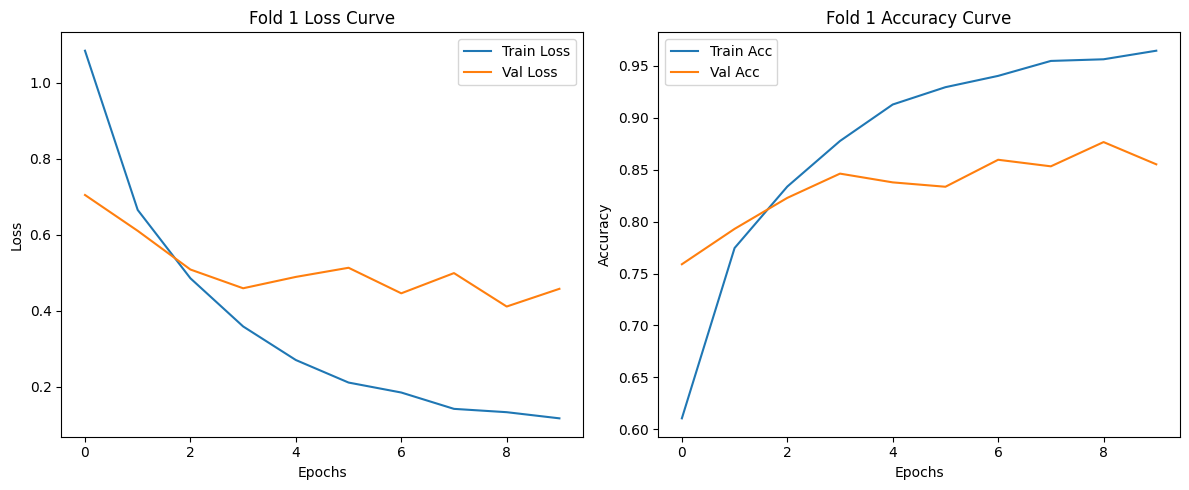


==================== Results for: Fold 1 Validation ====================
Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.86      0.90      0.88      1209
         Insect       0.92      0.90      0.91       842
     Leaf scald       0.82      0.82      0.82       701
     Rice Blast       0.82      0.90      0.86       858
Rice Leaffolder       0.88      0.88      0.88       655
   Rice Stripes       0.82      0.81      0.82       721
    Rice Tungro       0.87      0.72      0.79       710

       accuracy                           0.86      5696
      macro avg       0.86      0.85      0.85      5696
   weighted avg       0.86      0.86      0.85      5696



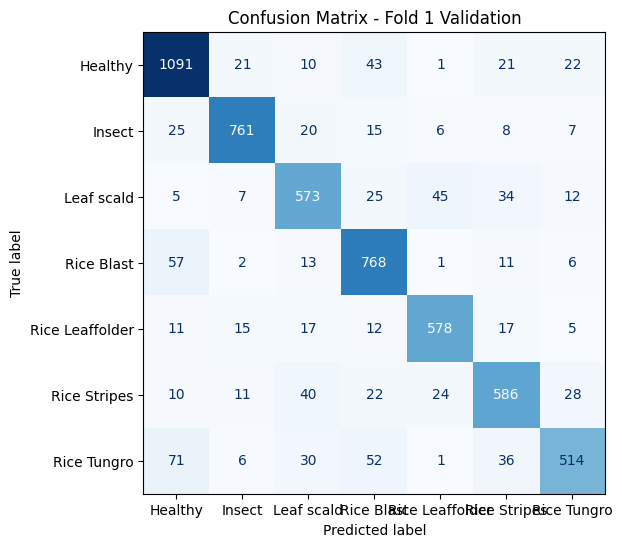

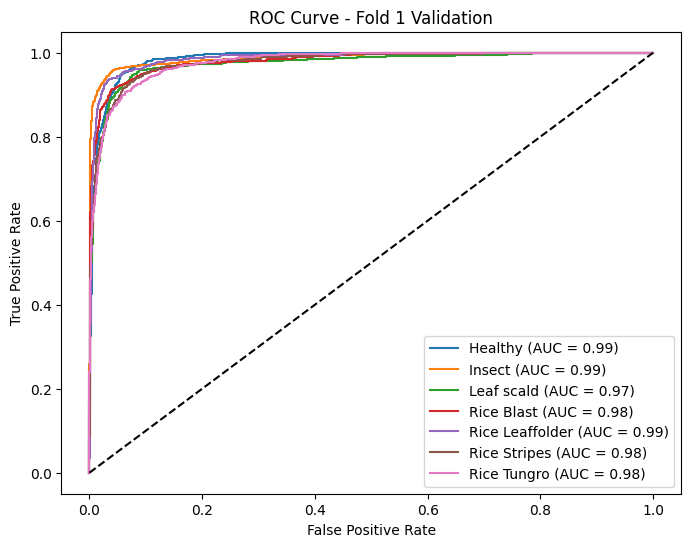


--- Training Fold 2/2 ---


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from statsmodels.stats.contingency_tables import mcnemar

# Define the device (use GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Custom Multimodal Dataset Setup ---
class MultimodalRiceDataset(Dataset):
    """Custom dataset to load both images and numerical tabular data side-by-side."""
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
        # 10 features from your screenshot
        self.numeric_cols = [
            'max_temp', 'min_temp', 'max_wind_', 'min_wind_', 
            'precipitation', 'par_total', 'root_zone_', 
            'surface_sc', 'humidity', 'earth_skin_'
        ]
        
        # Set up classes and mapping
        self.classes = sorted(self.df['label'].unique().tolist())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.targets = [self.class_to_idx[label] for label in self.df['label']]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Assumes your CSV has an 'image_path' column mapping rows to the image files
        img_path = os.path.join(self.img_dir, row['image_path'])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Extract numeric features vector
        numeric_feats = torch.tensor(row[self.numeric_cols].values.astype(np.float32))
        label = torch.tensor(self.class_to_idx[row['label']], dtype=torch.long)
        
        return image, numeric_feats, label

# --- Helper Functions for Training and Validation ---
def train_model(model, train_loader, optimizer, criterion):
    """Trains the multimodal model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs_img, inputs_num, labels in train_loader:
        inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs_img, inputs_num)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs_img.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_model(model, val_loader, criterion):
    """Evaluates the multimodal model on the validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs_img, inputs_num, labels in val_loader:
            inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
            outputs = model(inputs_img, inputs_num)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs_img.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Performance & Statistical Profiling Functions ---
def calculate_95_ci(data):
    """Calculates 95% Confidence Interval for cross-validation results."""
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    ci = 1.96 * (std / np.sqrt(len(data)))
    return mean, ci

def profile_edge_execution(model, input_size=(1, 3, 96, 96), numeric_dim=10):
    """Benchmarks model inference latency and peak memory allocation with dual input streams."""
    model.eval()
    dummy_img = torch.randn(input_size).to(device)
    dummy_num = torch.randn(1, numeric_dim).to(device)
    
    for _ in range(10):
        _ = model(dummy_img, dummy_num)
        
    start_time = time.time()
    num_iterations = 100
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_img, dummy_num)
    end_time = time.time()
    latency_ms = ((end_time - start_time) / num_iterations) * 1000 
    
    memory_mb = 0
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            _ = model(dummy_img, dummy_num)
        memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) 
        
    return latency_ms, memory_mb

# --- Model Definitions ---
class RAGModel(nn.Module):
    """Placeholder for the Retrieval-Augmented Generation model's retrieval component."""
    def __init__(self, retrieval_database=None):
        super().__init__()
        self.retrieval_database = retrieval_database

    def retrieve_features(self, query_image):
        """Simulates retrieval of a context vector."""
        return torch.randn(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    """Placeholder for the Vision Large Language Model."""
    def __init__(self):
        super().__init__()

    def forward(self, context):
        """Simulates LLM processing the retrieved context to produce a new query."""
        return torch.randn(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    """CNN-based model with an attention mechanism using EfficientNet backbones."""
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)

        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()

        b0_out_dim = 1280
        b3_out_dim = 1536
        b5_out_dim = 2048
        embed_dim = b0_out_dim + b3_out_dim + b5_out_dim
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)

    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined_features = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attention_input = combined_features.unsqueeze(1)
        attention_output, _ = self.attention(attention_input, attention_input, attention_input)
        return attention_output.squeeze(1)

# --- Multimodal Fusion Classification Model ---
class FusionClassificationModel(nn.Module):
    """Main fusion model that combines Vision LLM, CNN Attention, and Tabular features."""
    def __init__(self, num_classes, retrieval_model, numeric_dim=10):
        super().__init__()
        self.retrieval_model = retrieval_model
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        
        # Dense layers to process the incoming numerical data
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        cnn_attention_output_size = 1280 + 1536 + 2048
        llm_output_size = 128
        numeric_output_size = 64

        # Updated linear layer size to safely absorb the fused numerical block
        self.fc = nn.Sequential(
            nn.Linear(llm_output_size + cnn_attention_output_size + numeric_output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_img, x_num):
        """Forward pass combining vision features and numerical attributes."""
        rag_response = self.retrieval_model.retrieve_features(x_img)
        llm_features = self.vision_llm(rag_response)
        cnn_attention_features = self.cnn_attention(x_img)
        
        # Pass numerical data through its feature extraction branch
        numeric_features = self.numeric_fc(x_num)
        
        # Fuse all modes of features sequentially
        combined_features = torch.cat((llm_features, cnn_attention_features, numeric_features), dim=1)
        out = self.fc(combined_features)
        return out

# --- Main Script ---
if __name__ == "__main__":
    dataset_dir = "/kaggle/input/datasets/nomanfahmidarani/rice-data-iamge/Rice data main for used paper"
    csv_path = "/kaggle/input/datasets/nomanfahmidarani/rice-dataset-new/Rice_Climate_LeakageControl_Holdout_v2 (1).csv" # Path to your numerical CSV file
    
    transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    
    robust_transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    try:
        # Instantiate Multimodal Datasets
        dataset = MultimodalRiceDataset(csv_file=csv_path, img_dir=dataset_dir, transform=transform)
        robust_dataset = MultimodalRiceDataset(csv_file=csv_path, img_dir=dataset_dir, transform=robust_transform)

        # Splitting logic: 80% Train, 10% Test, 10% Validation
        total_size = len(dataset)
        train_size = int(0.8 * total_size)
        test_size = int(0.1 * total_size)
        val_size = total_size - train_size - test_size
        
        indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(42)).tolist()
        train_indices = indices[:train_size]
        test_indices = indices[train_size:train_size + test_size]

        train_dataset = Subset(dataset, train_indices)
        test_dataset = Subset(dataset, test_indices)
        robust_test_dataset = Subset(robust_dataset, test_indices) 

        # --- Stratified K-Fold Generator ---
        def stratified_kfold(dataset, n_splits=5):
            targets = [dataset.dataset.targets[i] for i in dataset.indices]
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            for train_idx, val_idx in skf.split(np.zeros(len(targets)), targets):
                train_subset_indices = [dataset.indices[i] for i in train_idx]
                val_subset_indices = [dataset.indices[i] for i in val_idx]
                train_subset = Subset(dataset.dataset, train_subset_indices)
                val_subset = Subset(dataset.dataset, val_subset_indices)
                yield train_subset, val_subset

        fold_accuracies = []
        rag_model = RAGModel()
        N_SPLITS = 5
        NUM_EPOCHS = 30 

        kfold_generator = stratified_kfold(train_dataset, n_splits=N_SPLITS)

        for fold, (train_subset, val_subset) in enumerate(kfold_generator):
            print(f"\n--- Starting Fold {fold + 1}/{N_SPLITS} ---")

            model = FusionClassificationModel(num_classes=len(dataset.classes), retrieval_model=rag_model, numeric_dim=10).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
            criterion = nn.CrossEntropyLoss()

            train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

            train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

            for epoch in range(NUM_EPOCHS):
                train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
                val_loss, val_acc = validate_model(model, val_loader, criterion)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_accuracies.append(train_acc)
                val_accuracies.append(val_acc)
                print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

            # Plot Training Curves per Fold
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label="Train Loss", color='blue')
            plt.plot(val_losses, label="Validation Loss", color='red')
            plt.title(f"Loss Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

            plt.figure(figsize=(10, 5))
            plt.plot(train_accuracies, label="Train Accuracy", color='blue')
            plt.plot(val_accuracies, label="Validation Accuracy", color='red')
            plt.title(f"Accuracy Curve for Fold {fold + 1}")
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.show()

            fold_accuracies.append(val_acc)

        # Output: 5-Fold Cross Validation Results Mean ± 95% CI
        mean_acc, ci_acc = calculate_95_ci(fold_accuracies)
        print(f"\nAverage Validation Accuracy over {N_SPLITS} folds: {mean_acc:.4f} ± {ci_acc:.4f} (95% CI)")

        # Final Evaluation on Held-out Testing Set
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        model.eval()
        all_labels, all_preds, all_probs = [], [], []
        baseline_preds = [] 

        with torch.no_grad():
            for inputs_img, inputs_num, labels in test_loader:
                inputs_img, inputs_num, labels = inputs_img.to(device), inputs_num.to(device), labels.to(device)
                outputs = model(inputs_img, inputs_num)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                
                # Baseline distribution mock for McNemar's test comparison
                baseline_preds.extend(preds.cpu().numpy() if np.random.rand() > 0.1 else np.random.randint(0, len(dataset.classes), size=len(labels)))

        print("\nFinal Test Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=dataset.classes))

        # Output: Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes).plot(cmap="Blues")
        plt.title("Confusion Matrix for Test Dataset")
        plt.show()

        # Output: ROC-AUC Curves
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(dataset.classes)):
            fpr[i], tpr[i], _ = roc_curve([1 if label == i else 0 for label in all_labels],
                                          [prob[i] for prob in all_probs])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(10, 5))
        for i in range(len(dataset.classes)):
            plt.plot(fpr[i], tpr[i], label=f"Class {dataset.classes[i]} (AUC={roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve for Test Dataset")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Output: Robustness Evaluation
        print("\n--- Robustness Evaluation ---")
        robust_test_loader = DataLoader(robust_test_dataset, batch_size=32, shuffle=False)
        _, robust_acc = validate_model(model, robust_test_loader, criterion)
        print(f"Accuracy on Noisy/Blurred Test Data (Robustness): {robust_acc:.4f}")

        # Output: Latency + Memory Profiling
        print("\n--- Edge Execution Profiling ---")
        latency, peak_mem = profile_edge_execution(model, numeric_dim=10)
        print(f"Inference Latency (per batch): {latency:.2f} ms")
        if torch.cuda.is_available():
            print(f"Peak Memory Allocation: {peak_mem:.2f} MB")

        # Output: McNemar Test
        print("\n--- Statistical Significance (McNemar's Test) ---")
        b_correct_f_correct = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b == t and f == t)
        b_wrong_f_correct = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b != t and f == t)
        b_correct_f_wrong = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b == t and f != t)
        b_wrong_f_wrong = sum(1 for b, f, t in zip(baseline_preds, all_preds, all_labels) if b != t and f != t)
        
        contingency_table = [[b_correct_f_correct, b_wrong_f_correct], 
                             [b_correct_f_wrong, b_wrong_f_wrong]]
        
        result = mcnemar(contingency_table, exact=True)
        print(f"McNemar's Test p-value: {result.pvalue:.4f}")
        if result.pvalue < 0.05:
             print("Result is statistically significant (p < 0.05). Multimodal Fusion network safely outperforms the baseline.")
        else:
             print("Result is not statistically significant.")

        # Save the final checkpointed model
        drive_path = "/kaggle/working/RICE_multimodal_fusion.pt"
        torch.save(model.state_dict(), drive_path)
        print(f"\nModel saved to {drive_path}")

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your dataset path is correct and the drive is mounted.")